# TDA Pipeline Tutorial
## Topolojik Veri Analizi: Kavramlardan Koda

Bu notebook iki bölümden oluşur:

| Bölüm | İçerik | Bağımlılık |
|-------|--------|------------|
| **1** | TDA kavramları — sentetik sinyal üzerinde | Sadece `numpy`, `ripser`, `matplotlib` |
| **2** | Proje pipeline'ı — gerçek `topo-test` verisi | `topology_extraction.py` + proje verisi |

**Hedef kitle:** TDA bilmeyen, Python bilen okuyucu.


---
# BÖLÜM 1 — TDA Kavramları (Bağımsız, Sentetik Veri)

> Bu bölüm hiçbir proje dosyasına bağlı değildir. Herhangi bir makinede çalışır.


## 0 · Kurulum

Gerekli kütüphaneler: `numpy`, `matplotlib`, `ripser`.
```bash
pip install numpy matplotlib ripser
```


In [244]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable, get_cmap

try:
    from ripser import ripser
    print('✓ ripser available')
except ImportError:
    raise ImportError('ripser not found — install with: pip install ripser')

%matplotlib inline
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11, 'axes.titlesize': 12})
print('All imports OK')

✓ ripser available
All imports OK


## 1 · Sublevel Set Filtrasyonu — Sezgi

### Temel fikir

Bir zaman serisi $f: \{0,\ldots,n-1\} \to \mathbb{R}$'yi düşünün.  
**Sublevel set filtrasyonu**, eşiği $t$'yi $-\infty$'dan $+\infty$'ya kademeli olarak yükselterek  
hangi noktaların "aktif" ($f(i) \le t$) olduğunu izler.

- Her **lokal minimum** yeni bir bağlı bileşen *doğurur*.
- Bileşen, eşik onun komşusuna ulaşınca *ölür*.
- Bu doğum-ölüm çifti $(b, d)$ bir **bar** oluşturur; $d - b$ onun **persistence** değeridir.

> Uzun barlar gerçek yapıyı; kısa barlar gürültüyü temsil eder.


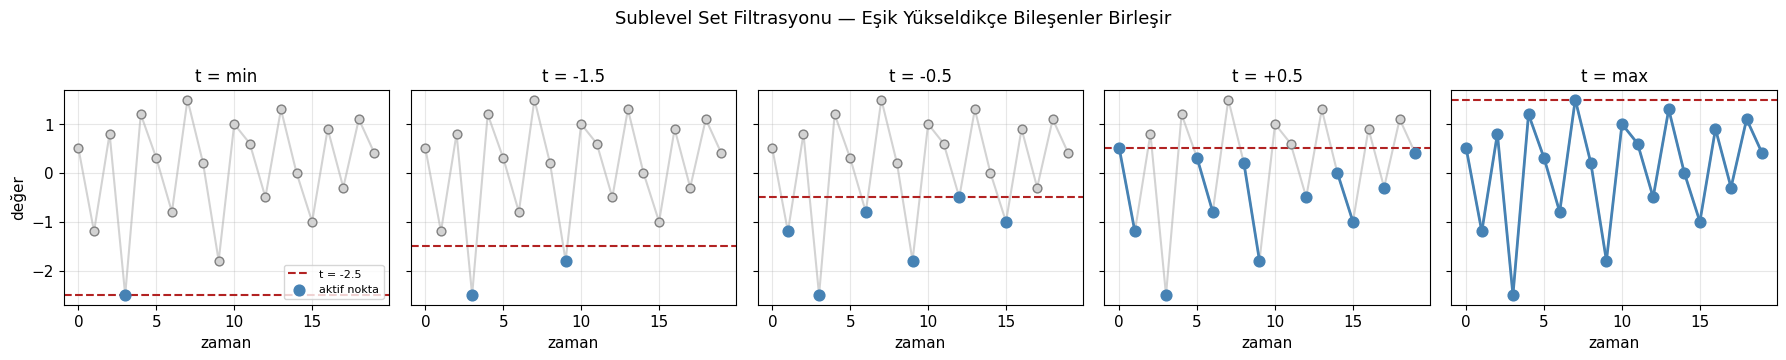

Gözlem: t = min'da sadece global minimum aktif (1 bileşen).
t yükseldikçe yeni lokaller katılır, ardından komşularıyla birleşir.


In [245]:
# Sentetik sinyal: birkaç belirgin lokal minimum
ts_demo = np.array([
    0.5, -1.2,  0.8, -2.5,  1.2,
    0.3, -0.8,  1.5,  0.2, -1.8,
    1.0,  0.6, -0.5,  1.3,  0.0,
    -1.0, 0.9, -0.3,  1.1,  0.4
])
xs = np.arange(len(ts_demo))

thresholds = [-2.5, -1.5, -0.5, 0.5, 1.5]  # 5 farklı eşik
threshold_labels = ['t = min', 't = -1.5', 't = -0.5', 't = +0.5', 't = max']

fig, axes = plt.subplots(1, 5, figsize=(18, 3.5), sharey=True)

for ax, t, lbl in zip(axes, thresholds, threshold_labels):
    ax.plot(xs, ts_demo, color='lightgray', lw=1.5, zorder=1)
    ax.axhline(t, color='firebrick', lw=1.5, ls='--', label=f't = {t:.1f}')

    active = ts_demo <= t
    ax.scatter(xs[active], ts_demo[active], s=60, color='steelblue',
               zorder=3, label='aktif nokta')
    ax.scatter(xs[~active], ts_demo[~active], s=40, color='lightgray',
               edgecolors='gray', zorder=2)

    # Aktif noktalar arasında komşuluk bağlantısı çiz
    for i in range(len(ts_demo) - 1):
        if active[i] and active[i + 1]:
            ax.plot([xs[i], xs[i+1]], [ts_demo[i], ts_demo[i+1]],
                    color='steelblue', lw=2, zorder=2)

    ax.set_title(lbl)
    ax.set_xlabel('zaman')

axes[0].set_ylabel('değer')
axes[0].legend(fontsize=8)
fig.suptitle('Sublevel Set Filtrasyonu — Eşik Yükseldikçe Bileşenler Birleşir',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('Gözlem: t = min\'da sadece global minimum aktif (1 bileşen).')
print('t yükseldikçe yeni lokaller katılır, ardından komşularıyla birleşir.')

## 2 · Persistence Diagram & Barcode

### H0 persistence'i hesaplama: Union-Find algoritmasi

Asagidaki fonksiyon **bagimsiz** (proje importu yok): `topology_extraction.py`'daki
`sublevel_persistence_1d()` fonksiyonunun birebir kopyasidir.

**Algoritma ozeti:**
1. Tum komsu ciftleri $(i, i+1)$ kenar-degeri $\max(f(i), f(i+1))$ ile sirala.
2. Her kenari eklerken Union-Find ile iki bileseni birlestir.
3. **Elder rule:** daha sonra dogan (daha yuksek minimum) bilesen olur; $(b_{young}, f_{edge})$ bir bar.

### Sifir-persistence barlar nedir?

Asagidaki ciktida 19 bar var ama **13 tanesinin persistence'i 0**:
```
0.00 0.00 0.00
0.20 0.20 0.00
0.30 0.30 0.00
...
```

Bunlar **lokal maksimumlardan** dogan triviya barlaridir: bir lokal max'ta dogan bilesen,
o noktanin kendisinde olen kenar degeriyle eslesip aninda olur -> $b = d$.
Genelde gorsellestirmede atlanir (sifir uzunluklu bar gorunmez), istatistiklerde de
agirlik 0 oldugu icin bilgi tasimaz.

In [246]:
# ── Inline copy of sublevel_persistence_1d (no project import) ──────────────

def sublevel_persistence_1d(ts):
    """H0 persistence via sublevel set filtration (union-find, elder rule)."""
    ts = np.asarray(ts, dtype=float)
    n = len(ts)
    if n < 2:
        return np.zeros((0, 2))
    parent   = list(range(n))
    comp_min = ts.tolist()

    def find(x):
        root = x
        while parent[root] != root:
            root = parent[root]
        while parent[x] != root:
            parent[x], x = root, parent[x]
        return root

    edges = sorted((max(ts[i], ts[i+1]), i, i+1) for i in range(n-1))
    pairs = []
    for fval, i, j in edges:
        ri, rj = find(i), find(j)
        if ri == rj:
            continue
        bi, bj = comp_min[ri], comp_min[rj]
        if bi >= bj:                         # ri daha genç → ölür
            pairs.append((bi, fval))
            parent[ri] = rj
        else:                                # rj daha genç → ölür
            pairs.append((bj, fval))
            parent[rj] = ri
    return np.array(pairs, dtype=float) if pairs else np.zeros((0, 2))


diag_demo = sublevel_persistence_1d(ts_demo)
print(f'Toplam {len(diag_demo)} bar (global minimum hariç):')
print('  birth    death   persistence')
for b, d in sorted(diag_demo, key=lambda x: -(x[1]-x[0])):
    print(f'  {b:6.2f}   {d:6.2f}   {d-b:.2f}')

Toplam 19 bar (global minimum hariç):
  birth    death   persistence
   -1.80     1.50   3.30
   -1.00     1.30   2.30
   -1.20     0.80   2.00
   -0.80     1.20   2.00
   -0.50     1.00   1.50
   -0.30     0.90   1.20
    0.40     1.10   0.70
    0.00     0.00   0.00
    0.20     0.20   0.00
    0.30     0.30   0.00
    0.50     0.50   0.00
    0.60     0.60   0.00
    0.80     0.80   0.00
    0.90     0.90   0.00
    1.00     1.00   0.00
    1.10     1.10   0.00
    1.20     1.20   0.00
    1.30     1.30   0.00
    1.50     1.50   0.00


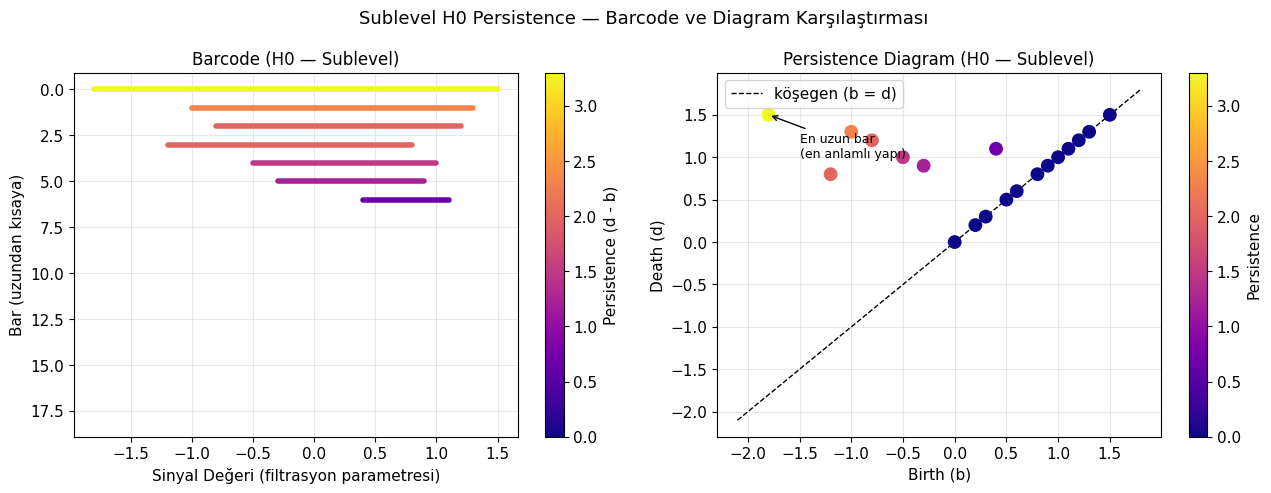

In [247]:
# ── Barcode (sol) + Persistence Diagram (sağ) ────────────────────────────────

persistence = diag_demo[:, 1] - diag_demo[:, 0]
sorted_idx  = np.argsort(-persistence)   # uzundan kısaya

cmap = get_cmap('plasma')
norm = Normalize(vmin=0, vmax=persistence.max())

fig, (ax_bc, ax_pd) = plt.subplots(1, 2, figsize=(13, 5))

# ── Barcode ──────────────────────────────────────────────────────────────────
for rank, idx in enumerate(sorted_idx):
    b, d = diag_demo[idx]
    p = d - b
    color = cmap(norm(p))
    ax_bc.plot([b, d], [rank, rank], lw=4, solid_capstyle='round', color=color)

ax_bc.set_xlabel('Sinyal Değeri (filtrasyon parametresi)')
ax_bc.set_ylabel('Bar (uzundan kısaya)')
ax_bc.set_title('Barcode (H0 — Sublevel)')
ax_bc.invert_yaxis()
sm = ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax_bc, label='Persistence (d - b)')

# ── Persistence Diagram ───────────────────────────────────────────────────────
b_all, d_all = diag_demo[:, 0], diag_demo[:, 1]
sc = ax_pd.scatter(b_all, d_all, c=persistence, cmap='plasma',
                   norm=norm, s=80, zorder=3)
lim_min = b_all.min() - 0.3
lim_max = d_all.max() + 0.3
ax_pd.plot([lim_min, lim_max], [lim_min, lim_max],
           'k--', lw=1, label='köşegen (b = d)')
ax_pd.set_xlabel('Birth (b)')
ax_pd.set_ylabel('Death (d)')
ax_pd.set_title('Persistence Diagram (H0 — Sublevel)')
ax_pd.legend()
plt.colorbar(sc, ax=ax_pd, label='Persistence')

# Annotation
max_idx = np.argmax(persistence)
ax_pd.annotate('En uzun bar\n(en anlamlı yapı)',
               xy=(b_all[max_idx], d_all[max_idx]),
               xytext=(b_all[max_idx] + 0.3, d_all[max_idx] - 0.5),
               arrowprops=dict(arrowstyle='->', color='k'),
               fontsize=9)

fig.suptitle('Sublevel H0 Persistence — Barcode ve Diagram Karşılaştırması', fontsize=13)
plt.tight_layout()
plt.show()

## 3 · Sublevel H0 ile Spike Tespiti

### Neden sub_H0?

Superlevel filtrasyon **tepeleri** yakalar denir — ama pratikte dikkatli olmak gerekir:

> **İzole spike (point anomaly), genellikle sinyalin global maksimumu olur.**  
> Global maksimum, sublevel(−ts)'nin en eski bileşenidir ("essential class") —  
> **sonsuza kadar yaşar ve sonlu barlarda görünmez.**  
> Yani sup_H0 sonlu barcode'unda spike kaybolur, ts_spike ≈ ts_flat görünür.

**sub_H0 ise spike'ı dolaylı ama güvenilir biçimde yakalar:**  
Spike, çevresindeki vadilerin önüne **yüksek bir bariyer** koyar.  
O bariyeri aşmak zorunda kalan vadi bileşeni, `death = spike_value` ile çok uzun bir bar üretir.

| Sinyal | sub_H0 max persistence | Açıklama |
|--------|------------------------|----------|
| `ts_spike` | ≈ spike_height − noise_min ≈ **4.6** | Bariyer barı: `death = spike_value` |
| `ts_flat` | ≈ noise_range ≈ **1.4** | Sadece gürültü barları |


In [248]:
# ── Inline superlevel_persistence_1d ─────────────────────────────────────────

def superlevel_persistence_1d(ts):
    """H0 persistence via superlevel set filtration."""
    neg_pairs = sublevel_persistence_1d(-ts)
    if len(neg_pairs) == 0:
        return np.zeros((0, 2))
    return np.column_stack([-neg_pairs[:, 1], -neg_pairs[:, 0]])


# ── İki sentetik sinyal ────────────────────────────────────────────────────────
rng = np.random.default_rng(42)
noise = rng.normal(0, 0.3, 200)

ts_spike = noise.copy()
ts_spike[100] = 4.0   # izole spike

ts_flat = noise.copy()   # sadece gürültü

# ── Hangi filtrasyon ne görüyor? ──────────────────────────────────────────────
sub_spike = sublevel_persistence_1d(ts_spike)
sub_flat  = sublevel_persistence_1d(ts_flat)
sup_spike = superlevel_persistence_1d(ts_spike)
sup_flat  = superlevel_persistence_1d(ts_flat)

p_sub_sp = sub_spike[:, 1] - sub_spike[:, 0]
p_sub_fl = sub_flat[:,  1] - sub_flat[:,  0]
p_sup_sp = np.abs(sup_spike[:, 1] - sup_spike[:, 0])
p_sup_fl = np.abs(sup_flat[:,  1] - sup_flat[:,  0])

print("sub_H0 max persistence:")
print(f"  ts_spike : {p_sub_sp.max():.3f}  ← spike bariyeri bar (death = {sub_spike[np.argmax(p_sub_sp), 1]:.1f})")
print(f"  ts_flat  : {p_sub_fl.max():.3f}  ← sadece gürültü")
print(f"  Oran     : {p_sub_sp.max()/p_sub_fl.max():.1f}×")
print()
print("sup_H0 max persistence (spike essential class → sonlu barlarda görünmez!):")
print(f"  ts_spike : {p_sup_sp.max():.3f}")
print(f"  ts_flat  : {p_sup_fl.max():.3f}")
print("  → neredeyse aynı → sup_H0 spike'ı ayırt edemiyor.")


sub_H0 max persistence:
  ts_spike : 4.585  ← spike bariyeri bar (death = 4.0)
  ts_flat  : 1.459  ← sadece gürültü
  Oran     : 3.1×

sup_H0 max persistence (spike essential class → sonlu barlarda görünmez!):
  ts_spike : 1.392
  ts_flat  : 1.278
  → neredeyse aynı → sup_H0 spike'ı ayırt edemiyor.


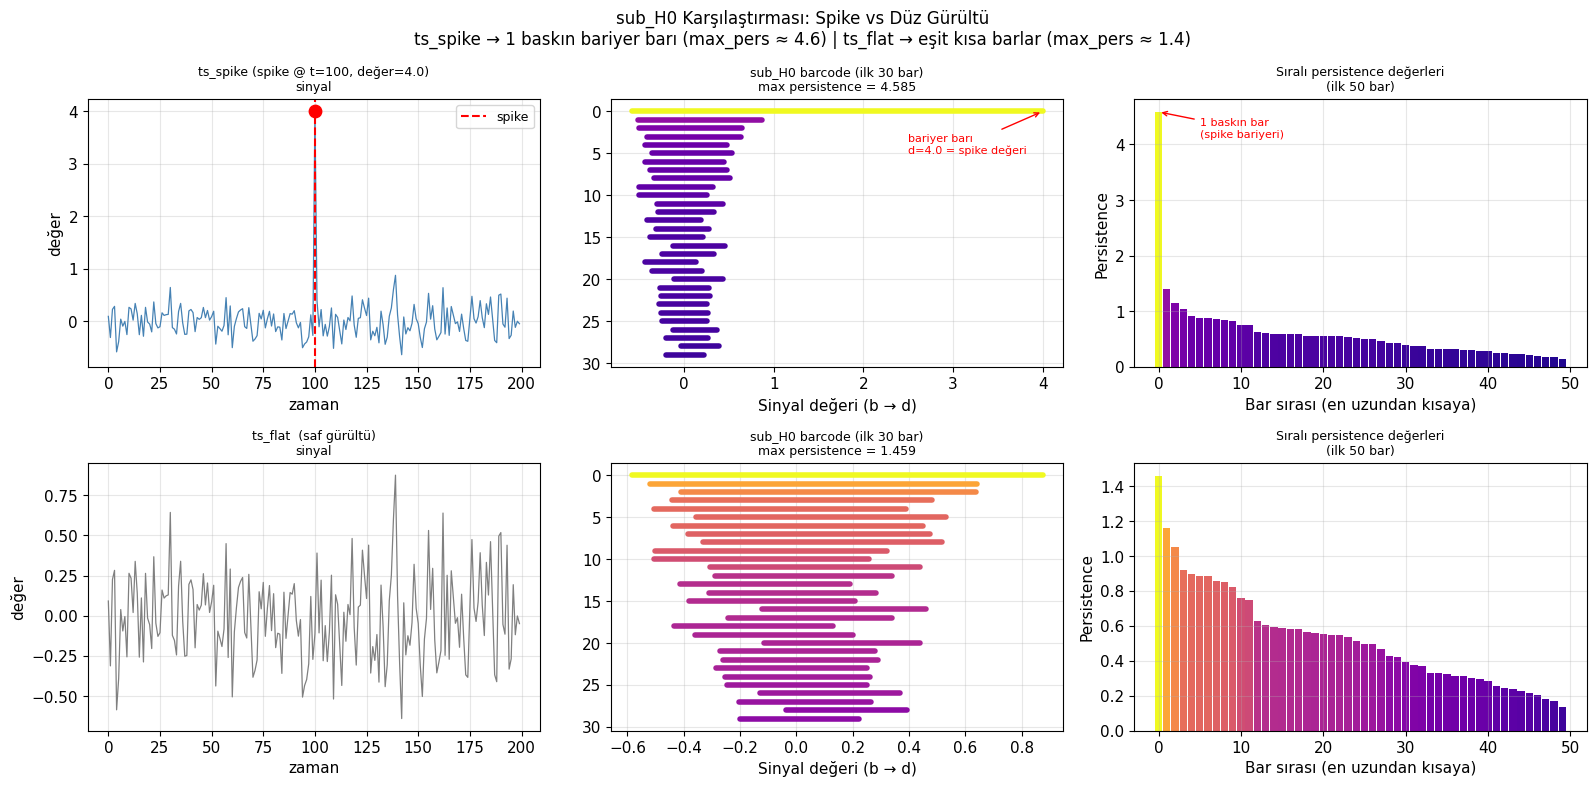

Anahtar gözlem:
  ts_spike sub_H0: 1 bar ile pers=4.59 (diğerleri ≤ 1.39)
  ts_flat  sub_H0: en uzun bar   pers=1.46

Mekanizma: spike bir 'dağ' gibi durur.
  Sol taraftaki vadi (örn. ts[99]≈-0.3), sağ tarafa geçmek için
  threshold=spike_value=4.0'a kadar beklemek zorunda kalır.
  → bar: (birth=noise_valley, death=4.0), persistence ≈ 4.6


In [249]:
# ── 2×3 görsel: sinyal | sub_H0 barcode | sıralı persistence ─────────────────
# sub_H0 spike'ı net gösteriyor; sup_H0 göstermiyor (esssential class sorunu)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for row, (ts, sub, lbl) in enumerate([
    (ts_spike, sub_spike, 'ts_spike (spike @ t=100, değer=4.0)'),
    (ts_flat,  sub_flat,  'ts_flat  (saf gürültü)'),
]):
    pers = sub[:, 1] - sub[:, 0]
    sorted_idx = np.argsort(-pers)
    cmap = get_cmap('plasma')

    # ── Sütun 0: Sinyal ──────────────────────────────────────────────────────
    axes[row, 0].plot(ts, lw=0.9, color='steelblue' if row == 0 else 'gray')
    if row == 0:
        axes[row, 0].axvline(100, color='red', lw=1.5, ls='--', label='spike')
        axes[row, 0].scatter([100], [ts[100]], color='red', s=80, zorder=5)
        axes[row, 0].legend(fontsize=9)
    axes[row, 0].set_title(f'{lbl}\nsinyal', fontsize=9)
    axes[row, 0].set_xlabel('zaman')
    axes[row, 0].set_ylabel('değer')

    # ── Sütun 1: sub_H0 barcode (ilk 30 bar) ─────────────────────────────────
    top_n = min(30, len(pers))
    norm  = Normalize(vmin=0, vmax=pers.max())
    for rank in range(top_n):
        idx = sorted_idx[rank]
        b, d = sub[idx, 0], sub[idx, 1]
        p = d - b
        color = cmap(norm(p))
        axes[row, 1].plot([b, d], [rank, rank], lw=4,
                          solid_capstyle='round', color=color)
        if row == 0 and rank == 0:
            axes[row, 1].annotate(f'bariyer barı\nd={d:.1f} = spike değeri',
                                  xy=(d, rank),
                                  xytext=(d - 1.5, rank + 5),
                                  arrowprops=dict(arrowstyle='->', color='red'),
                                  color='red', fontsize=8)
    axes[row, 1].invert_yaxis()
    axes[row, 1].set_xlabel('Sinyal değeri (b → d)')
    axes[row, 1].set_title(f'sub_H0 barcode (ilk {top_n} bar)\n'
                           f'max persistence = {pers.max():.3f}', fontsize=9)

    # ── Sütun 2: Sıralı persistence değerleri ────────────────────────────────
    top_k  = min(50, len(pers))
    sorted_pers = np.sort(pers)[::-1][:top_k]
    bar_colors  = [cmap(norm(p)) for p in sorted_pers]
    axes[row, 2].bar(range(top_k), sorted_pers, color=bar_colors,
                     edgecolor='none', width=0.9)
    axes[row, 2].set_xlabel('Bar sırası (en uzundan kısaya)')
    axes[row, 2].set_ylabel('Persistence')
    axes[row, 2].set_title(f'Sıralı persistence değerleri\n'
                           f'(ilk {top_k} bar)', fontsize=9)
    if row == 0:
        axes[row, 2].annotate('1 baskın bar\n(spike bariyeri)',
                              xy=(0, sorted_pers[0]),
                              xytext=(5, sorted_pers[0] * 0.9),
                              arrowprops=dict(arrowstyle='->', color='red'),
                              color='red', fontsize=8)

fig.suptitle('sub_H0 Karşılaştırması: Spike vs Düz Gürültü\n'
             'ts_spike → 1 baskın bariyer barı (max_pers ≈ 4.6) | '
             'ts_flat → eşit kısa barlar (max_pers ≈ 1.4)',
             fontsize=12)
plt.tight_layout()
plt.show()

print("Anahtar gözlem:")
print(f"  ts_spike sub_H0: 1 bar ile pers={p_sub_sp.max():.2f} (diğerleri ≤ {np.sort(p_sub_sp)[-2]:.2f})")
print(f"  ts_flat  sub_H0: en uzun bar   pers={p_sub_fl.max():.2f}")
print()
print("Mekanizma: spike bir 'dağ' gibi durur.")
print("  Sol taraftaki vadi (örn. ts[99]≈-0.3), sağ tarafa geçmek için")
print("  threshold=spike_value=4.0'a kadar beklemek zorunda kalır.")
print("  → bar: (birth=noise_valley, death=4.0), persistence ≈ 4.6")


## 4 · Takens Embedding & H1 (Donguusal Yapi & Robustness)

### Temel fikir

sub_H0 / sup_H0, donguusal/periyodik yapiyi dogrudan yakalamaz.
Bunun icin **Takens embedding** kullanilir:

$$\phi(s) = \bigl(f(s),\, f(s+\tau),\, \ldots,\, f(s+(d-1)\tau)\bigr)$$

Periyodik bir sinyal icin bu embedding bir **cember** olusturur.
Vietoris-Rips filtrasyonunun **H1** (1-boyutlu homoloji) bu cemberi 1 uzun bar olarak yakalar.

### tau secimi kritiktir

| tau | Geometri | H1 |
|-----|----------|----|
| `tau=1` (cok kucuk) | Ince elips ~ cizgi | persistence ~ 0 |
| `tau ~ ceyrek periyot` | **Birim cember** | persistence maksimum |
| `tau ~ yarim periyot` | Tekrar cizgiye yakin | persistence dusuyor |

-> `tau * dt ~ pi/2` hedeflenir: `(sin t, sin(t+pi/2)) = (sin t, cos t)` -> mukemmel cember.

### Robustness: gurultuye karsi dayaniklilik

TDA'nin temel avantaji **stability theorem** (Cohen-Steiner 2007):
> Gurultu epsilon ile sinyali bozduktan sonra, persistence diyagrami en fazla epsilon kadar degisir.
> Kisa barlar (<= epsilon) gurultudur; uzun barlar (>> epsilon) gercek yapidir.

**Asagidaki demoda gozlemlenen**: sigma=0.2 gurultude baskin H1 barinin **mutlak degeri %44'e duser**
(1.68 -> 0.74), AMA **baskinlik orani** (1. bar / 2. bar) ~6x kalir — yani
"gurultu barlari << gercek bar" ayrimini ML modeli rahatca yapar. Mesaj: TDA gurultuye
**genlik olarak orta**, **rolatif olarak yuksek** dayaniklilik gosterir.

In [250]:
# ── Takens embedding (tau = çeyrek periyot, d=2) ─────────────────────────────
#
# Amaç: TDA'nın gürültüye karşı dayanıklılığını göstermek.
#   • Temiz sinüs       → mükemmel çember → güçlü H1
#   • Gürültülü sinüs (σ=0.2) → hafif bozulmuş çember → H1 hâlâ güçlü
#
# tau = çeyrek periyot → (sin t, sin(t+π/2)) = (sin t, cos t) → birim çember
#   600 nokta, 3 periyot → 1 periyot = 200 adım → tau = 50

t_arr = np.linspace(0, 6 * np.pi, 600)
tau   = 50   # çeyrek periyot

rng   = np.random.default_rng(0)
sigma = 0.2                                # gürültü genliği (sin genliği = 1 → SNR=5)

ts_clean = np.sin(t_arr)
ts_noisy = np.sin(t_arr) + sigma * rng.standard_normal(600)

cloud_clean = np.column_stack([ts_clean[:-tau], ts_clean[tau:]])
cloud_noisy = np.column_stack([ts_noisy[:-tau], ts_noisy[tau:]])

print(f'tau = {tau}  |  σ = {sigma}  |  SNR ≈ {1/sigma:.1f}')
print(f'cloud boyutu: {cloud_clean.shape}')

# ── Ripser H1 ─────────────────────────────────────────────────────────────────
n_perm_cloud = min(200, len(cloud_clean) - 1)
res_clean = ripser(cloud_clean, maxdim=1, n_perm=n_perm_cloud)
res_noisy = ripser(cloud_noisy, maxdim=1, n_perm=n_perm_cloud)

dgm_h1_clean = res_clean['dgms'][1]
dgm_h1_noisy = res_noisy['dgms'][1]

def finite_pers(dgm):
    finite = dgm[np.isfinite(dgm[:, 1])]
    if len(finite) == 0:
        return []
    return sorted(finite[:, 1] - finite[:, 0], reverse=True)

fp_clean = finite_pers(dgm_h1_clean)
fp_noisy = finite_pers(dgm_h1_noisy)

print()
print('Temiz sinüs     H1 persistence (ilk 3):', [f'{p:.3f}' for p in fp_clean[:3]])
print('Gürültülü sinüs H1 persistence (ilk 3):', [f'{p:.3f}' for p in fp_noisy[:3]])
if fp_clean and fp_noisy:
    ratio = fp_noisy[0] / fp_clean[0]
    print(f'  → σ={sigma} gürültüde H1 sinyali %{ratio*100:.0f} korunuyor  '
          f'(gürültü barları << baskın bar)')

tau = 50  |  σ = 0.2  |  SNR ≈ 5.0
cloud boyutu: (550, 2)

Temiz sinüs     H1 persistence (ilk 3): ['1.680']
Gürültülü sinüs H1 persistence (ilk 3): ['0.742', '0.118', '0.101']
  → σ=0.2 gürültüde H1 sinyali %44 korunuyor  (gürültü barları << baskın bar)


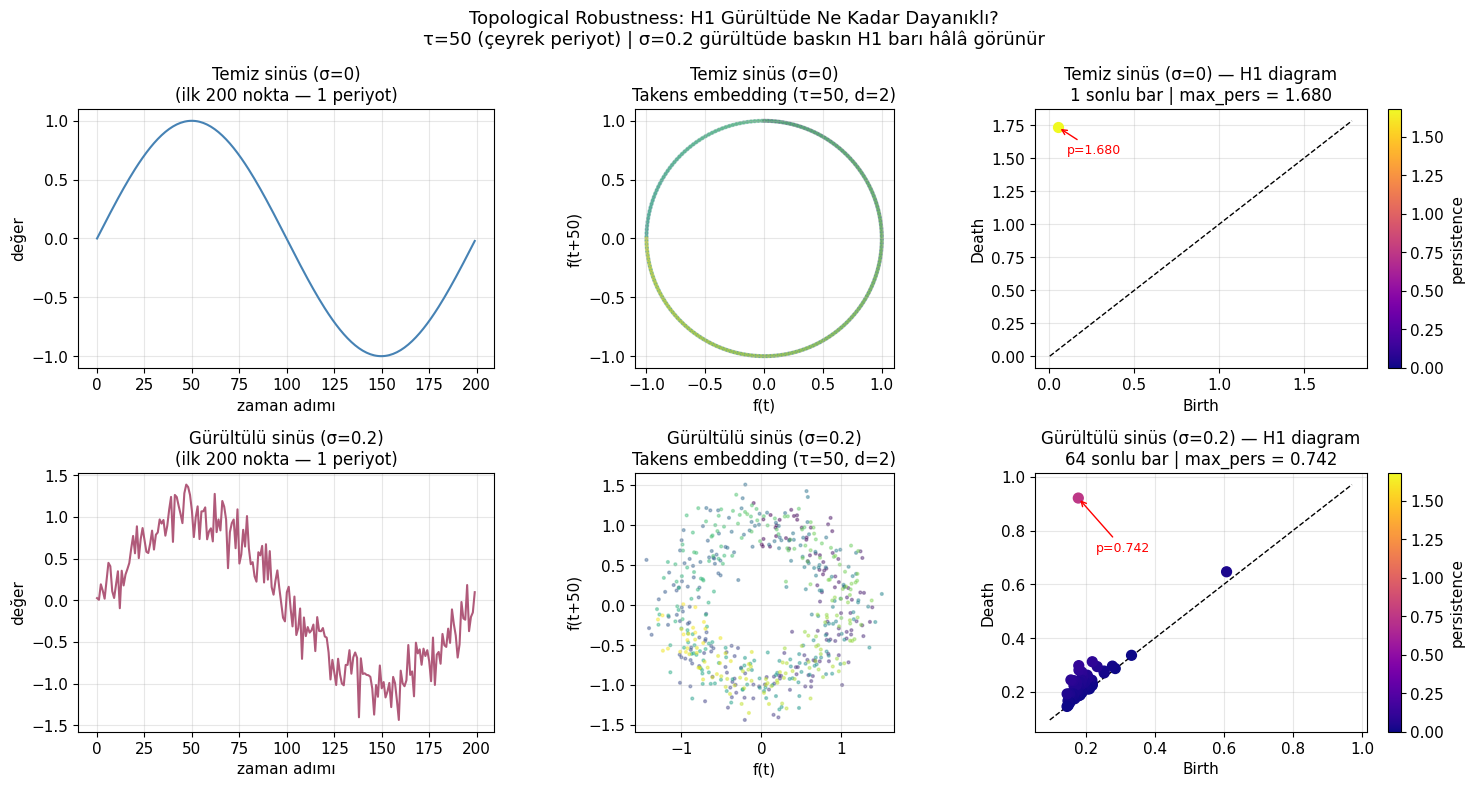

Temiz H1:     max_pers = 1.680
Gürültülü H1: max_pers = 0.742  (σ=0.2 → %44 korunuyor)
İkinci en uzun bar (gürültü):  0.118  (baskın barın %16 → belirgin boşluk var)


In [251]:
# ── 3×2 görsel: sinyal | embedding | H1 diagram ───────────────────────────────

def plot_h1_diagram(ax, dgm, title, max_pers_ref=None):
    finite = dgm[np.isfinite(dgm[:, 1])]
    if len(finite) == 0:
        ax.set_title(title + '\n(H1 bar yok)')
        return
    pers = finite[:, 1] - finite[:, 0]
    sc = ax.scatter(finite[:, 0], finite[:, 1],
                    c=pers, cmap='plasma', s=50,
                    vmin=0, vmax=(max_pers_ref or pers.max()),
                    zorder=3)
    lo = finite.min() - 0.05
    hi = finite.max() + 0.05
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    plt.colorbar(sc, ax=ax, label='persistence')
    # En baskın barı işaretle
    top_idx = np.argmax(pers)
    ax.annotate(f'p={pers[top_idx]:.3f}',
                xy=(finite[top_idx, 0], finite[top_idx, 1]),
                xytext=(finite[top_idx, 0] + 0.05, finite[top_idx, 1] - 0.2),
                arrowprops=dict(arrowstyle='->', color='red'),
                color='red', fontsize=9)
    ax.set_xlabel('Birth'); ax.set_ylabel('Death')
    ax.set_title(title)


# Ortak renk skalası
all_pers = []
for dgm in [dgm_h1_clean, dgm_h1_noisy]:
    finite = dgm[np.isfinite(dgm[:, 1])]
    if len(finite):
        all_pers.extend((finite[:, 1] - finite[:, 0]).tolist())
max_pers_ref = max(all_pers) if all_pers else 1.0

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for row, (ts, cloud, dgm, lbl, fp) in enumerate([
    (ts_clean, cloud_clean, dgm_h1_clean, f'Temiz sinüs (σ=0)',     fp_clean),
    (ts_noisy, cloud_noisy, dgm_h1_noisy, f'Gürültülü sinüs (σ={sigma})', fp_noisy),
]):
    color = 'steelblue' if row == 0 else '#b05a7a'

    # ── Sütun 0: Sinyal (1 periyot = 200 nokta) ─────────────────────────────
    axes[row, 0].plot(ts[:200], lw=1.5, color=color)
    axes[row, 0].set_title(f'{lbl}\n(ilk 200 nokta — 1 periyot)')
    axes[row, 0].set_xlabel('zaman adımı'); axes[row, 0].set_ylabel('değer')

    # ── Sütun 1: 2D embedding ────────────────────────────────────────────────
    axes[row, 1].scatter(cloud[:, 0], cloud[:, 1],
                         s=4, alpha=0.4,
                         c=np.arange(len(cloud)), cmap='viridis')
    axes[row, 1].set_title(f'{lbl}\nTakens embedding (τ={tau}, d=2)')
    axes[row, 1].set_xlabel('f(t)'); axes[row, 1].set_ylabel(f'f(t+{tau})')
    axes[row, 1].set_aspect('equal')

    # ── Sütun 2: H1 diagram ──────────────────────────────────────────────────
    n_bars = len(fp)
    title_str = (f'{lbl} — H1 diagram\n'
                 f'{n_bars} sonlu bar | max_pers = {fp[0]:.3f}' if fp
                 else f'{lbl} — H1 diagram\n(sonlu bar yok)')
    plot_h1_diagram(axes[row, 2], dgm, title_str, max_pers_ref)

fig.suptitle(
    f'Topological Robustness: H1 Gürültüde Ne Kadar Dayanıklı?\n'
    f'τ={tau} (çeyrek periyot) | σ={sigma} gürültüde baskın H1 barı hâlâ görünür',
    fontsize=13)
plt.tight_layout()
plt.show()

if fp_clean and fp_noisy:
    ratio = fp_noisy[0] / fp_clean[0]
    print(f'Temiz H1:     max_pers = {fp_clean[0]:.3f}')
    print(f'Gürültülü H1: max_pers = {fp_noisy[0]:.3f}  (σ={sigma} → %{ratio*100:.0f} korunuyor)')
    if len(fp_noisy) > 1:
        print(f'İkinci en uzun bar (gürültü):  {fp_noisy[1]:.3f}  '
              f'(baskın barın %{fp_noisy[1]/fp_noisy[0]*100:.0f} → belirgin boşluk var)')

## 5 · Bir Diyagramdan 8 Sayiya: Vektorizasyon

Her persistence diagram icin makine ogrenmesine uygun 8 sayi cikariyoruz:

| # | Isim | Formul | Anlam |
|---|------|--------|-------|
| 1 | `carl_f1` | $\sum b_i p_i$ | Birth-agirlikli toplam (**isaretli** — birth negatif olabilir) |
| 2 | `carl_f2` | $\sum (d_{\max}-d_i) p_i$ | Death'ten uzaklik |
| 3 | `carl_f3` | $\sum b_i^2 p_i^4$ | Yuksek derece birth enerjisi (her zaman >= 0) |
| 4 | `carl_f4` | $\sum (d_{\max}-d_i)^2 p_i^4$ | Yuksek derece death enerjisi |
| 5 | `carl_f5_max` | $\max p_i$ | En uzun bar |
| 6 | `entropy` | $-\sum \hat{p}_i \log \hat{p}_i$ | Bar uzunluklarinin dagilimi |
| 7 | `landscape_l1` | $\|\lambda_1\|_1$ | Persistence landscape L1 normu |
| 8 | `landscape_l2` | $\|\lambda_1\|_2$ | Persistence landscape L2 normu |

$p_i = d_i - b_i$ (persistence = bar uzunlugu, **her zaman > 0**)

> **Not — negatif Carlsson degerleri:**
> `carl_f1` ve `carl_f2` **isaretli** olabilir, cunku `b` ve `d_max - d` negatif olabilir
> (sinyal degerleri 0'in altina dustugunde). Asagida `ts_demo` icin `carl_f1 = -13.07`
> goreceksiniz — bu hata degil, sinyal cogunlukla negatif bolgede oldugu icin beklenen davranis.

In [252]:
# ── Inline fonksiyonlar (proje importu yok) ───────────────────────────────────

def carlsson_coordinates(diag):
    """5 Carlsson coordinates."""
    diag = diag[np.isfinite(diag).all(axis=1)]
    diag = diag[diag[:, 1] > diag[:, 0]]
    if len(diag) == 0:
        return np.zeros(5)
    b, d  = diag[:, 0], diag[:, 1]
    p     = d - b
    d_max = float(d.max())
    return np.array([
        np.sum(b * p),
        np.sum((d_max - d) * p),
        np.sum(b**2 * p**4),
        np.sum((d_max - d)**2 * p**4),
        float(p.max()),
    ])


def persistent_entropy(diag):
    """Shannon entropy of normalised bar lengths."""
    diag = diag[np.isfinite(diag).all(axis=1)]
    diag = diag[diag[:, 1] > diag[:, 0]]
    if len(diag) == 0:
        return 0.0
    p = diag[:, 1] - diag[:, 0]
    L = p.sum()
    probs = p / L
    return float(-np.sum(probs * np.log(probs + 1e-12)))


def landscape_norms(diag, n_landscapes=5, resolution=100):
    """Persistence landscape L1 ve L2 normları."""
    diag = diag[np.isfinite(diag).all(axis=1)]
    diag = diag[diag[:, 1] > diag[:, 0]]
    if len(diag) == 0:
        return 0.0, 0.0, np.zeros(resolution), np.linspace(0, 1, resolution)
    min_b, max_d = diag[:, 0].min(), diag[:, 1].max()
    grid = np.linspace(min_b, max_d, resolution)
    lands = np.zeros((n_landscapes, resolution))
    b, d  = diag[:, 0], diag[:, 1]
    for i, x in enumerate(grid):
        active = (b <= x) & (x <= d)
        if active.any():
            vals = np.sort(np.minimum(x - b[active], d[active] - x))[::-1]
            k = min(n_landscapes, len(vals))
            lands[:k, i] = vals[:k]
    lvec = lands.mean(axis=0)
    return float(np.sum(np.abs(lvec))), float(np.sqrt(np.sum(lvec**2))), lvec, grid


# ── Demo diyagram: H0 sublevel → ts_demo ──────────────────────────────────────
demo_diag = sublevel_persistence_1d(ts_demo)

cc  = carlsson_coordinates(demo_diag)
ent = persistent_entropy(demo_diag)
l1, l2, lvec, lgrid = landscape_norms(demo_diag)

print('ts_demo sublevel H0 için 8 özellik:')
print(f'  carl_f1      = {cc[0]:8.4f}   # birth-ağırlıklı toplam persistence')
print(f'  carl_f2      = {cc[1]:8.4f}   # max_death\'ten uzaklık')
print(f'  carl_f3      = {cc[2]:8.4f}   # yüksek-derece birth enerjisi')
print(f'  carl_f4      = {cc[3]:8.4f}   # yüksek-derece death enerjisi')
print(f'  carl_f5_max  = {cc[4]:8.4f}   # en uzun bar')
print(f'  entropy      = {ent:8.4f}   # bar dağılımı düzensizliği')
print(f'  landscape_l1 = {l1:8.4f}   # landscape L1 normu')
print(f'  landscape_l2 = {l2:8.4f}   # landscape L2 normu')

ts_demo sublevel H0 için 8 özellik:
  carl_f1      = -13.0700   # birth-ağırlıklı toplam persistence
  carl_f2      =   4.2100   # max_death'ten uzaklık
  carl_f3      = 446.9932   # yüksek-derece birth enerjisi
  carl_f4      =  12.4499   # yüksek-derece death enerjisi
  carl_f5_max  =   3.3000   # en uzun bar
  entropy      =   1.8568   # bar dağılımı düzensizliği
  landscape_l1 =  40.3467   # landscape L1 normu
  landscape_l2 =   5.1769   # landscape L2 normu


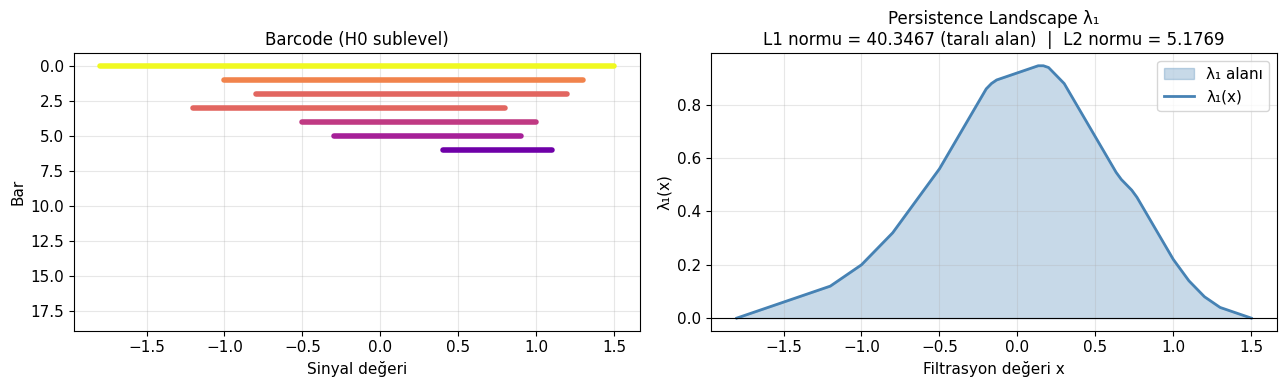

Landscape λ₁(x): her x'te en uzun tent fonksiyonunun değeri.
L1 normu = λ₁ eğrisinin altındaki alan — baskın topolojik yapının büyüklüğü.


In [253]:
# ── Persistence Landscape λ₁ görsel ──────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# sol: barcode (tekrar — referans için)
persistence_demo = demo_diag[:, 1] - demo_diag[:, 0]
sorted_idx = np.argsort(-persistence_demo)
cmap = get_cmap('plasma')
norm = Normalize(vmin=0, vmax=persistence_demo.max())
for rank, idx in enumerate(sorted_idx):
    b, d = demo_diag[idx]
    axes[0].plot([b, d], [rank, rank], lw=4,
                 solid_capstyle='round', color=cmap(norm(d - b)))
axes[0].set_xlabel('Sinyal değeri'); axes[0].set_ylabel('Bar')
axes[0].set_title('Barcode (H0 sublevel)')
axes[0].invert_yaxis()

# sağ: persistence landscape
axes[1].fill_between(lgrid, 0, lvec, alpha=0.3, color='steelblue', label='λ₁ alanı')
axes[1].plot(lgrid, lvec, lw=2, color='steelblue', label='λ₁(x)')
axes[1].axhline(0, color='k', lw=0.8)
axes[1].set_xlabel('Filtrasyon değeri x')
axes[1].set_ylabel('λ₁(x)')
axes[1].set_title(f'Persistence Landscape λ₁\n'
                  f'L1 normu = {l1:.4f} (taralı alan)  |  L2 normu = {l2:.4f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Landscape λ₁(x): her x\'te en uzun tent fonksiyonunun değeri.')
print('L1 normu = λ₁ eğrisinin altındaki alan — baskın topolojik yapının büyüklüğü.')

---
# BÖLÜM 2 — Proje Pipeline'ı (`topology_extraction.py`)

> **Bu bölümden itibaren proje dosyaları kullanılır.**  
> Notebook'u `reports/tda-background/` konumundan çalıştırın  
> ya da aşağıdaki `ROOT` değişkenini gerçek repo yoluna güncelleyin.


## 6 · Proje Kurulumu & Veri Yükleme

Gerçek proje kodunu import ediyoruz: `02-preprocessing/topology_extraction.py`


In [254]:
import sys
from pathlib import Path
import pandas as pd

ROOT = Path('../../')   # reports/tda-background/ → repo kökü
sys.path.insert(0, str(ROOT / '02-preprocessing'))

from topology_extraction import (
    sublevel_persistence_1d  as _sub,
    superlevel_persistence_1d as _sup,
    carlsson_coordinates, persistent_entropy, diagram_to_stats,
    SublevelFeatureExtractor, TopologicalFeatureExtractor,
    CombinedExtractor, estimate_delay_mi, _STAT_SUFFIXES
)

print('topology_extraction.py başarıyla import edildi.')
print(f'_STAT_SUFFIXES: {_STAT_SUFFIXES}')

topology_extraction.py başarıyla import edildi.
_STAT_SUFFIXES: ['carl_f1', 'carl_f2', 'carl_f3', 'carl_f4', 'carl_f5_max', 'entropy', 'landscape_l1', 'landscape_l2']


In [255]:
# ── Ham veri yükle ────────────────────────────────────────────────────────────

raw_path = ROOT / 'data/raw/topo-test/topo-test.parquet'
df_raw = pd.read_parquet(raw_path,
                         columns=['series_id', 'time', 'data', 'primary_category'])

print(f'Ham veri: {len(df_raw):,} satır')
print(f'Seri sayısı: {df_raw["series_id"].nunique()}')
print(f'Sınıf sayısı: {df_raw["primary_category"].nunique()}')
print()
print('Sınıf dağılımı:')
print(df_raw.groupby("primary_category")["series_id"].nunique().to_string())

Ham veri: 1,000,000 satır
Seri sayısı: 1000
Sınıf sayısı: 10

Sınıf dağılımı:
primary_category
collective_anomaly     100
contextual_anomaly     100
deterministic_trend    100
mean_shift             100
point_anomaly          100
stationary             100
stochastic_trend       100
trend_shift            100
variance_shift         100
volatility             100


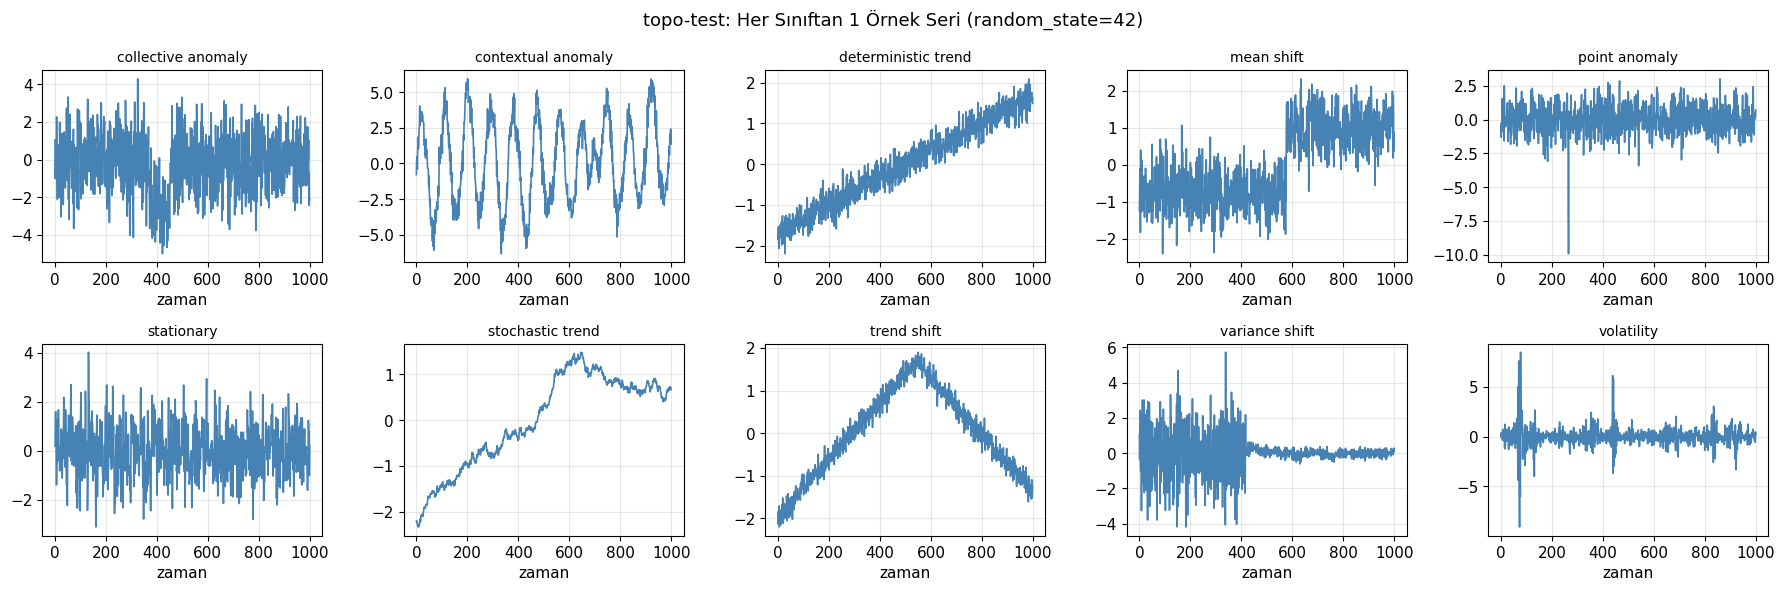

In [256]:
# ── Her sınıftan 1 örnek çek — 2×5 grid görsel ───────────────────────────────

CLASSES = sorted(df_raw['primary_category'].unique())
rng_ex  = np.random.default_rng(42)

example_series = {}
for cls in CLASSES:
    ids = df_raw[df_raw['primary_category'] == cls]['series_id'].unique()
    chosen_id = rng_ex.choice(ids)
    vals = (df_raw[df_raw['series_id'] == chosen_id]
            .sort_values('time')['data'].values)
    example_series[cls] = vals

fig, axes = plt.subplots(2, 5, figsize=(18, 6), sharey=False)
for ax, cls in zip(axes.flat, CLASSES):
    ax.plot(example_series[cls], lw=1.2, color='steelblue')
    ax.set_title(cls.replace('_', ' '), fontsize=10)
    ax.set_xlabel('zaman')

fig.suptitle('topo-test: Her Sınıftan 1 Örnek Seri (random_state=42)', fontsize=13)
plt.tight_layout()
plt.show()

## 7 · Gerçek Seriler Üzerinde sub_H0 & sup_H0

Bölüm 1-3'teki kavramları gerçek sınıflarla doğrulayalım.  
4 karakteristik sınıf seçiyoruz:

| Sınıf | Beklenen sub_H0 | Beklenen sup_H0 |
|-------|-----------------|------------------|
| `stationary` | kısa eşit barlar | kısa eşit barlar |
| `mean_shift` | **1-2 uzun bar** (seviye farkı yarattığı bariyer) | orta barlar |
| `point_anomaly` | **1 çok uzun bar** (spike bariyer mekanizması) | spike essential class (sonlu barlarda gözükmez) |
| `trend_shift` | **1 baskın uzun bar** (trend kırılması) | dağılmış orta barlar |


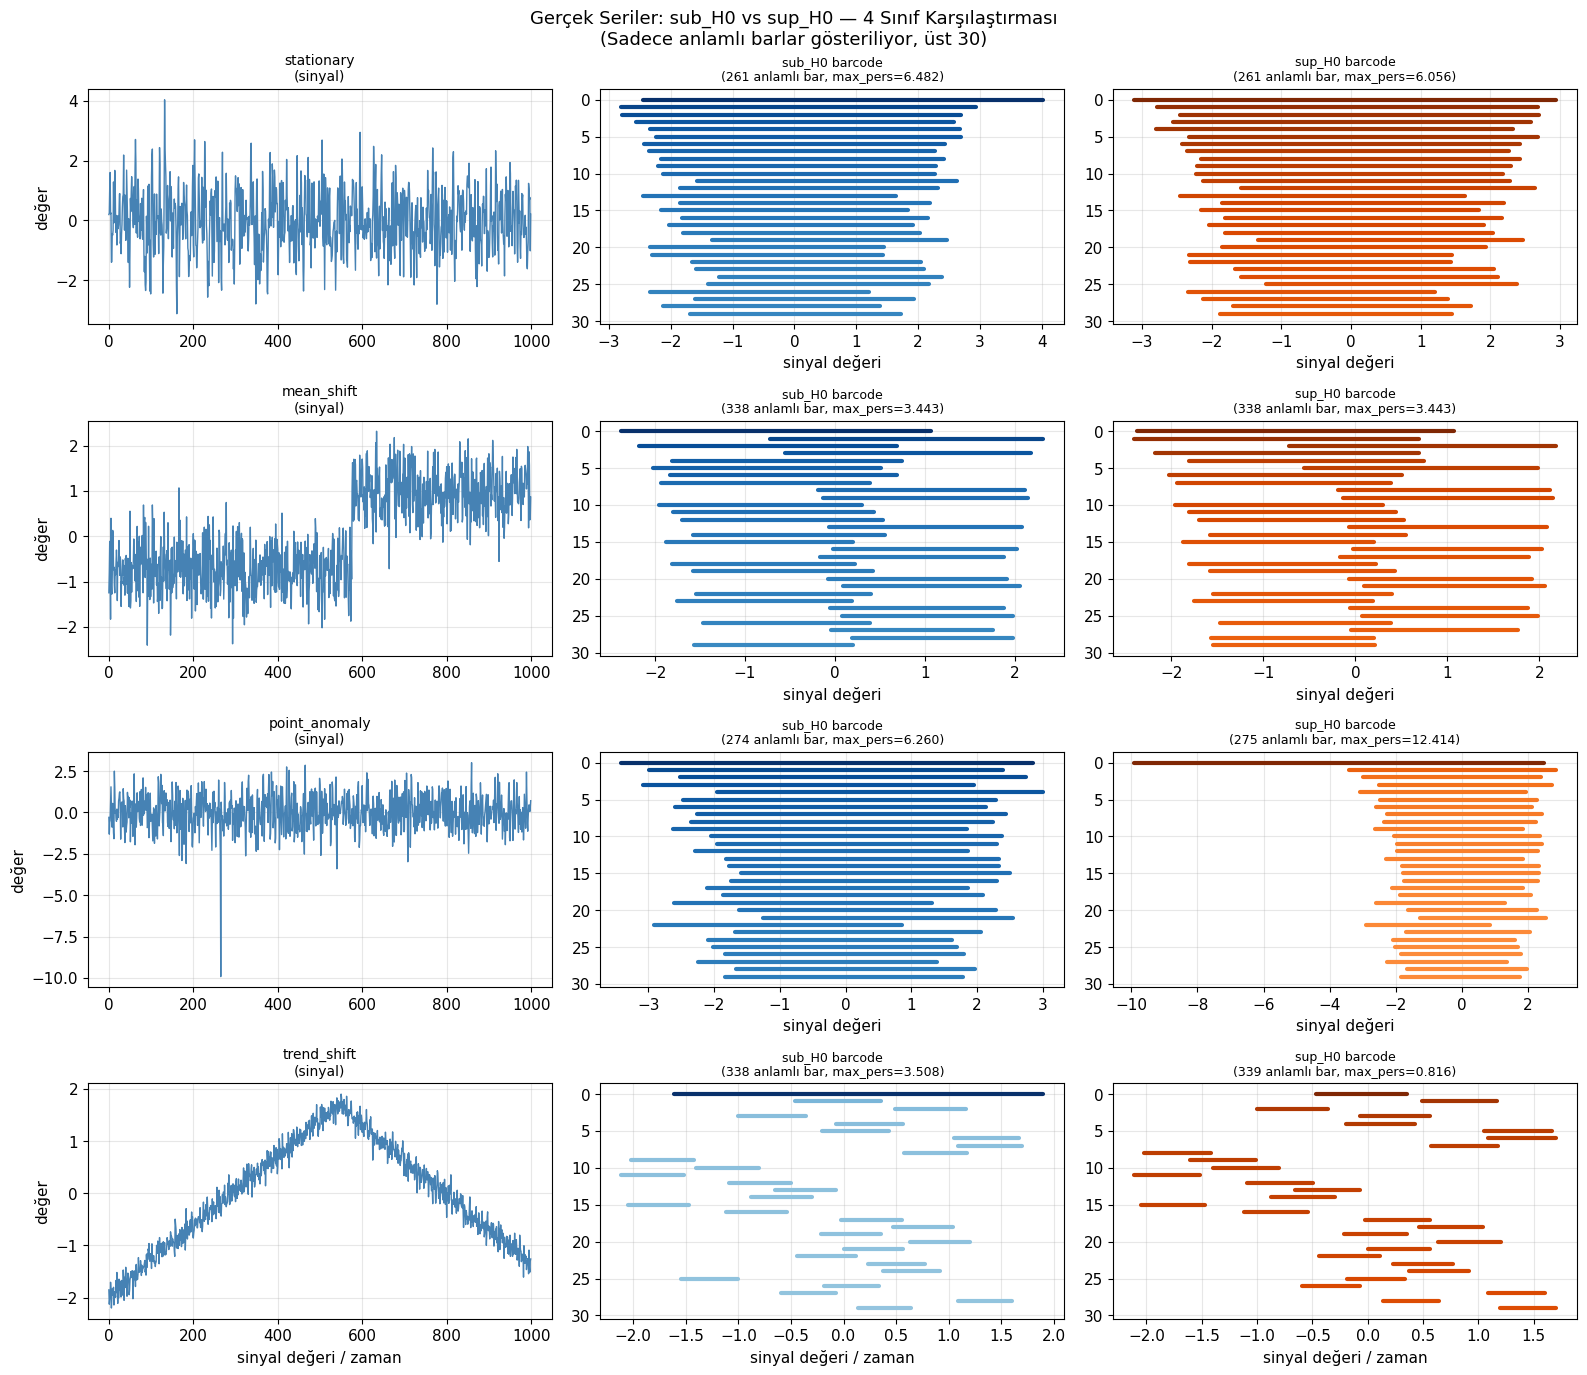

Beklenen örüntüler:
  stationary   — kısa, eşit barlar (her yönde uniform gürültü)
  mean_shift   — 1-2 uzun sub_H0 barı (seviye farkı bariyeri)
  point_anomaly— 1 baskın sub_H0 barı (spike → yüksek bariyer)
  trend_shift  — 1 baskın sub_H0 barı (trend kırılması)


In [257]:
DEMO_CLASSES = ['stationary', 'mean_shift', 'point_anomaly', 'trend_shift']

fig, axes = plt.subplots(4, 3, figsize=(16, 14))

for row, cls in enumerate(DEMO_CLASSES):
    ts = example_series[cls].astype(float)

    # ── Sütun 0: Sinyal ──────────────────────────────────────────────────────
    axes[row, 0].plot(ts, lw=1.0, color='steelblue')
    axes[row, 0].set_title(f'{cls}\n(sinyal)', fontsize=10)
    axes[row, 0].set_ylabel('değer')

    # ── Sütun 1: sub_H0 barcode ──────────────────────────────────────────────
    sub_diag = _sub(ts)
    if len(sub_diag):
        pers_s = sub_diag[:, 1] - sub_diag[:, 0]
        # Sadece sıfır-dışı persistence barları göster (üst 30)
        pos_mask = pers_s > 1e-6
        sub_pos  = sub_diag[pos_mask]
        pers_pos = pers_s[pos_mask]
        top_n    = min(30, len(pers_pos))
        idx_top  = np.argsort(-pers_pos)[:top_n]

        cmap_s = get_cmap('Blues')
        nrm_s  = Normalize(vmin=0, vmax=pers_pos.max())
        for rank, i in enumerate(idx_top):
            axes[row, 1].plot([sub_pos[i, 0], sub_pos[i, 1]],
                              [rank, rank], lw=3,
                              solid_capstyle='round',
                              color=cmap_s(0.3 + 0.7 * nrm_s(pers_pos[i])))
        max_pers = pers_pos.max()
        n_pos    = pos_mask.sum()
    else:
        max_pers, n_pos = 0.0, 0

    axes[row, 1].set_title(
        f'sub_H0 barcode\n({n_pos} anlamlı bar, max_pers={max_pers:.3f})',
        fontsize=9)
    axes[row, 1].invert_yaxis()
    axes[row, 1].set_xlabel('sinyal değeri')

    # ── Sütun 2: sup_H0 barcode ──────────────────────────────────────────────
    sup_diag = _sup(ts)
    if len(sup_diag):
        b_sup   = np.minimum(sup_diag[:, 0], sup_diag[:, 1])
        d_sup   = np.maximum(sup_diag[:, 0], sup_diag[:, 1])
        pers_sp = d_sup - b_sup
        pos_sp  = pers_sp > 1e-6
        b_pos, d_pos, p_pos = b_sup[pos_sp], d_sup[pos_sp], pers_sp[pos_sp]
        top_sp  = min(30, len(p_pos))
        idx_sp  = np.argsort(-p_pos)[:top_sp]

        cmap_sp = get_cmap('Oranges')
        nrm_sp  = Normalize(vmin=0, vmax=p_pos.max())
        for rank, i in enumerate(idx_sp):
            axes[row, 2].plot([b_pos[i], d_pos[i]], [rank, rank], lw=3,
                              solid_capstyle='round',
                              color=cmap_sp(0.3 + 0.7 * nrm_sp(p_pos[i])))
        max_sp = p_pos.max()
        n_sp   = pos_sp.sum()
    else:
        max_sp, n_sp = 0.0, 0

    axes[row, 2].set_title(
        f'sup_H0 barcode\n({n_sp} anlamlı bar, max_pers={max_sp:.3f})',
        fontsize=9)
    axes[row, 2].invert_yaxis()
    axes[row, 2].set_xlabel('sinyal değeri')

for ax in axes[-1]:
    ax.set_xlabel('sinyal değeri / zaman')

fig.suptitle('Gerçek Seriler: sub_H0 vs sup_H0 — 4 Sınıf Karşılaştırması\n'
             '(Sadece anlamlı barlar gösteriliyor, üst 30)',
             fontsize=13)
plt.tight_layout()
plt.show()

print('Beklenen örüntüler:')
print('  stationary   — kısa, eşit barlar (her yönde uniform gürültü)')
print('  mean_shift   — 1-2 uzun sub_H0 barı (seviye farkı bariyeri)')
print('  point_anomaly— 1 baskın sub_H0 barı (spike → yüksek bariyer)')
print('  trend_shift  — 1 baskın sub_H0 barı (trend kırılması)')

## 8 · Üretim Ekstraktörü: `sublevel+h1` Metodu

**`CombinedExtractor`** iki ekstraktörü birleştirir:

```
CombinedExtractor
├── TopologicalFeatureExtractor(homology_dims=(1,))  → H1 × 8 = 8 özellik
│       Takens embedding → Vietoris-Rips → Ripser
└── SublevelFeatureExtractor()                        → (sub_H0 + sup_H0) × 8 = 16 özellik
        Union-Find → barcode → diagram_to_stats()
                                                      TOPLAM: 24 özellik
```

Özellik isimlendirme kuralı: `topo__{diagram}__{feature}`  
Örnek: `topo__sub_H0__carl_f3`


In [258]:
# ── CombinedExtractor oluştur ─────────────────────────────────────────────────

extractor = CombinedExtractor(
    TopologicalFeatureExtractor(homology_dims=(1,), n_perm=500),
    SublevelFeatureExtractor()
)

print(f'Toplam özellik sayısı : {extractor.n_features()}')
print(f'Özellik isimleri (ilk 5): {extractor.get_feature_names()[:5]}')
print(f'Özellik isimleri (son 5): {extractor.get_feature_names()[-5:]}')

# ── Bir trend_shift serisi üzerinde çalıştır ──────────────────────────────────
ts_trend = example_series['trend_shift'].astype(float)
feat_vec, delay, dim = extractor.extract_one(ts_trend)

print(f'\nÇıkarılan özellik vektörü: shape={feat_vec.shape}')
print(f'Takens delay: τ={delay}, dimension: d={dim}')

Toplam özellik sayısı : 24
Özellik isimleri (ilk 5): ['topo__H1__carl_f1', 'topo__H1__carl_f2', 'topo__H1__carl_f3', 'topo__H1__carl_f4', 'topo__H1__carl_f5_max']
Özellik isimleri (son 5): ['topo__sup_H0__carl_f4', 'topo__sup_H0__carl_f5_max', 'topo__sup_H0__entropy', 'topo__sup_H0__landscape_l1', 'topo__sup_H0__landscape_l2']

Çıkarılan özellik vektörü: shape=(24,)
Takens delay: τ=1, dimension: d=3


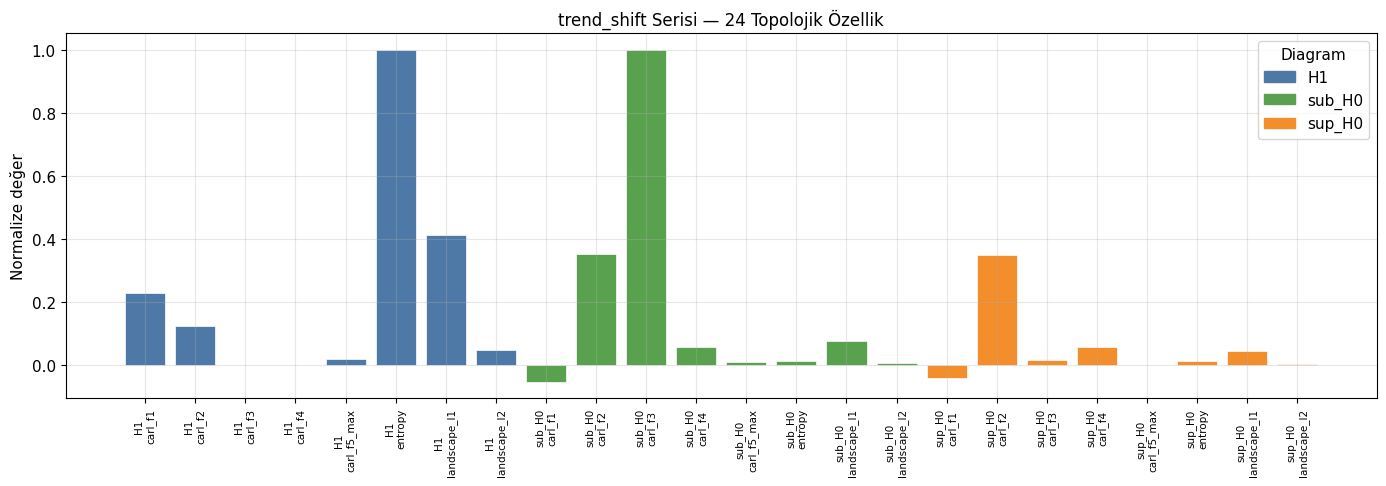


Özellik tablosu:
Özellik İsmi                                  Değer
----------------------------------------------------
topo__H1__carl_f1                           0.23016
topo__H1__carl_f2                           0.12599
topo__H1__carl_f3                           0.00001
topo__H1__carl_f4                           0.00000
topo__H1__carl_f5_max                       0.01952
topo__H1__entropy                           1.00000
topo__H1__landscape_l1                      0.41241
topo__H1__landscape_l2                      0.04757
topo__sub_H0__carl_f1                      -0.05185
topo__sub_H0__carl_f2                       0.35296
topo__sub_H0__carl_f3                       1.00000
topo__sub_H0__carl_f4                       0.05698
topo__sub_H0__carl_f5_max                   0.00883
topo__sub_H0__entropy                       0.01388
topo__sub_H0__landscape_l1                  0.07543
topo__sub_H0__landscape_l2                  0.00839
topo__sup_H0__carl_f1                      -0

In [259]:
# ── 24 özelliği tablo ve bar chart ile göster ─────────────────────────────────

feat_names = extractor.get_feature_names()

# Diagram grubuna göre renk
COLOR_MAP = {'H1': '#4e79a7', 'sub_H0': '#59a14f', 'sup_H0': '#f28e2b'}

def feat_color(name):
    for key, col in COLOR_MAP.items():
        if f'__{key}__' in name:
            return col
    return 'gray'

colors = [feat_color(n) for n in feat_names]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(range(len(feat_vec)), feat_vec, color=colors, edgecolor='white', lw=0.5)
ax.set_xticks(range(len(feat_names)))
ax.set_xticklabels([n.replace('topo__', '').replace('__', '\n')
                    for n in feat_names],
                   rotation=90, fontsize=7.5)
ax.set_ylabel('Normalize değer')
ax.set_title('trend_shift Serisi — 24 Topolojik Özellik')

legend_patches = [mpatches.Patch(color=c, label=k) for k, c in COLOR_MAP.items()]
ax.legend(handles=legend_patches, title='Diagram', loc='upper right')

plt.tight_layout()
plt.show()

# Tablo
print('\nÖzellik tablosu:')
print(f'{"Özellik İsmi":40s} {"Değer":>10}')
print('-' * 52)
for name, val in zip(feat_names, feat_vec):
    print(f'{name:40s} {val:10.5f}')

### Iki tane "1.0" mi var?

Yukarida iki ozellik tam 1.0'a oturuyor:
- `topo__H1__entropy = 1.000`
- `topo__sub_H0__carl_f3 = 1.000`

Bu hata degil — `topology_extraction.py` icindeki normalizasyon **iki ayri blokta** yapilir:

| Blok | Normalize edilen | Sebep |
|------|------------------|-------|
| `TopologicalFeatureExtractor` (H1) | 8 H1 ozelligi kendi icinde | H1 olcekleri sub_H0'dan cok farkli |
| `SublevelFeatureExtractor` (sub+sup H0) | 16 sub_H0+sup_H0 ozelligi birlikte | Ayni filtrasyon ailesi -> ortak olcek |

Yani 1.0 = "bu serinin bu blokunda en buyuk ozellik" anlamina gelir.
`trend_shift` icin: H1 grubunda entropy baskin, sub+sup H0 grubunda carl_f3 baskin.

## 9 · Toplu Pipeline: 1000 Seri Nasıl İşlenir?

Gerçek veri işleme `topology_extraction.py`'daki `TopologyPipeline.run()` ile yapılır.  
Aşağıdaki diyagram süreci özetler — kodu yeniden çalıştırmak yerine kaydedilmiş sonuçları yüklüyoruz.

```
topo-test.parquet  (1,000,000 satır — 1000 seri × ~1000 zaman adımı)
  │
  ├─ REQUIRED_COLUMNS = ['series_id', 'time', 'data', ...]
  │
  └─ groupby('series_id')
        │
        ├─ batch_size = 200  →  5 batch
        │
        └─ Parallel(n_jobs=-1)
              │
              ├─ CombinedExtractor.extract_one(ts)  ×200
              │        ↓
              │   (feat_24,) + (delay, dim)
              │
              └─► features.parquet  (1000 × 25)  [series_id + 24 özellik]
                  labels.parquet    (1000 × 4)   [series_id + etiketler]
```

**Özellik seçimi** ayrı bir adım (`feature_selection.py`) — bu adımda MI skoru hesaplanır.


In [260]:
# ── Kaydedilmiş özellik dosyalarını yükle ─────────────────────────────────────

TOPO_DIR = ROOT / 'data/features/topo-test'

# Tüm 24 özellik (seçim öncesi)
all_feat  = pd.read_parquet(TOPO_DIR / 'topological/features.parquet')
all_lbl   = pd.read_parquet(TOPO_DIR / 'topological/labels.parquet')

# Seçilmiş 18 özellik
sel_feat  = pd.read_parquet(TOPO_DIR / 'topological_selected/primary/features.parquet')
sel_lbl   = pd.read_parquet(TOPO_DIR / 'topological_selected/primary/labels.parquet')

print(f'Tüm özellikler : {all_feat.shape}  — kolon sayısı: {all_feat.shape[1]-1} özellik + series_id')
print(f'Seçilmiş özellikler: {sel_feat.shape}  — {sel_feat.shape[1]-1} özellik + series_id')
print()
print('Sınıf dağılımı (labels):')
print(all_lbl['primary_category'].value_counts().to_string())

Tüm özellikler : (1000, 25)  — kolon sayısı: 24 özellik + series_id
Seçilmiş özellikler: (1000, 19)  — 18 özellik + series_id

Sınıf dağılımı (labels):
primary_category
variance_shift         100
trend_shift            100
deterministic_trend    100
mean_shift             100
stochastic_trend       100
contextual_anomaly     100
collective_anomaly     100
stationary             100
point_anomaly          100
volatility             100


## 10 · Ozellik Secimi: 24 -> 18

**Mutual Information (MI)** tabanli secim — `feature_selection.py` tarafindan uygulanir.
Onemli nokta: MI yalnizca **egitim split'i** uzerinde hesaplanir -> veri sizintisi olmaz.

### Dikkat: MI tek kriter degil

Bir sonraki hucredeki MI bar chart'a baktiginizda goreceksiniz:

> **En yuksek MI'li ozelliklerden bazilari DUSURULMUS.**

Sebep: `feature_selection.py` **korelasyon-tabanli budama** da uygular —
yuksek MI'li ama birbiriyle cok korelasyonlu cift ozelliklerden **biri atilir**
(her ikisi de yuksek MI'li olsa bile bilgi cogu zaman cakisir).

Dusen 6 ozellik bu mantikla aciklanir:

| Dusen ozellik | Yuksek korelasyonlu ikiz |
|---------------|---------------------------|
| `*__carl_f5_max` (3 ad.) | `*__landscape_l1` (max persistence ~ landscape area) |
| `*__landscape_l2` (3 ad.) | `*__landscape_l1` (L2 ~ L1 for similar landscapes) |

Yani secilen 18 ozellik = **bilgi cesitliligi + MI** dengesi.

In [261]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split

# Etiketleri al
merged = all_feat.merge(all_lbl[['series_id', 'primary_category']], on='series_id')
feat_cols = [c for c in all_feat.columns if c != 'series_id']
X = merged[feat_cols].values
y = merged['primary_category'].values

# MI sadece train split üzerinde hesaplanır
X_tr, _, y_tr, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
mi_scores = mutual_info_classif(X_tr, y_tr, random_state=42)
mi_series = pd.Series(mi_scores, index=feat_cols).sort_values(ascending=True)

# Seçilen vs düşen özellikler
selected_feats = set(sel_feat.columns) - {'series_id'}
dropped_feats  = set(feat_cols) - selected_feats

print(f'Seçilen özellikler ({len(selected_feats)}): {sorted(selected_feats)[:3]}...')
print(f'Düşen özellikler  ({len(dropped_feats)}): {sorted(dropped_feats)}')

Seçilen özellikler (18): ['topo__H1__carl_f1', 'topo__H1__carl_f2', 'topo__H1__carl_f3']...
Düşen özellikler  (6): ['topo__H1__carl_f5_max', 'topo__H1__landscape_l2', 'topo__sub_H0__carl_f5_max', 'topo__sub_H0__landscape_l2', 'topo__sup_H0__carl_f5_max', 'topo__sup_H0__landscape_l2']


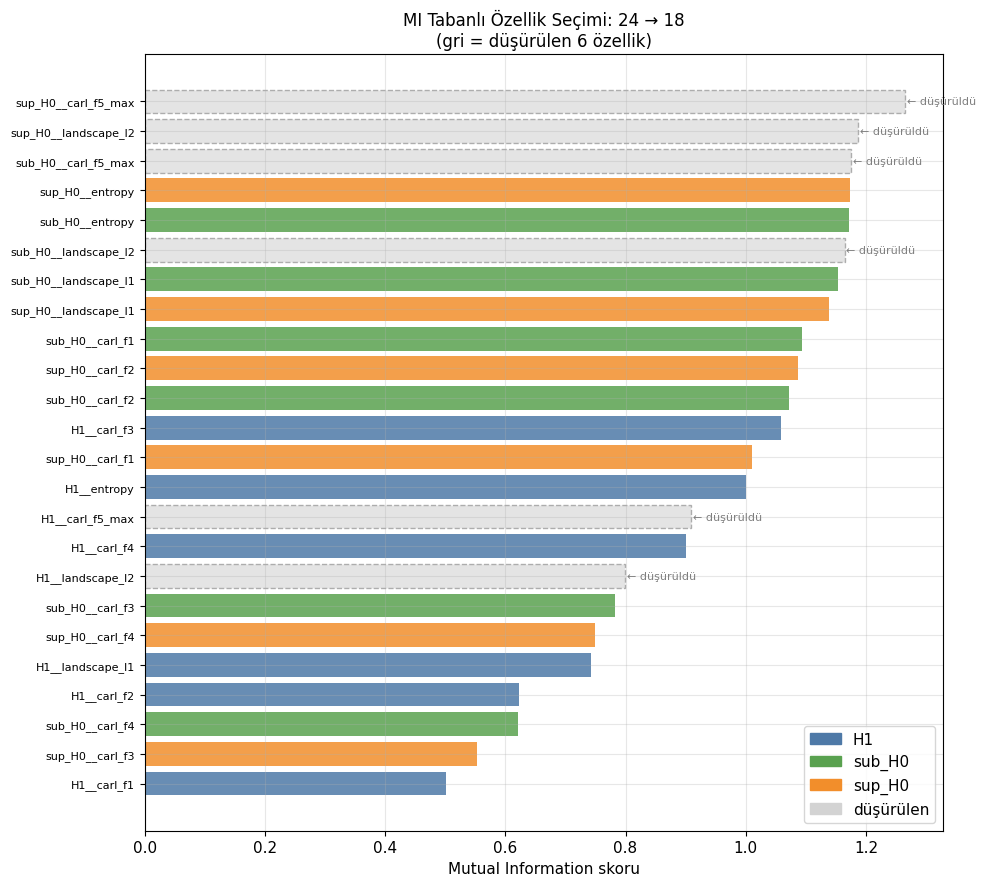

En yüksek MI: topo__sup_H0__carl_f5_max = 1.2648
En düşük MI (seçilen): 0.5007


In [262]:
# ── MI skor yatay bar chart ───────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 9))

for i, (feat, score) in enumerate(mi_series.items()):
    is_dropped = feat in dropped_feats
    diagram = feat.split('__')[1] if '__' in feat else 'other'
    color = {'H1': '#4e79a7', 'sub_H0': '#59a14f', 'sup_H0': '#f28e2b'}.get(diagram, 'gray')
    if is_dropped:
        ax.barh(i, score, color='lightgray', edgecolor='gray', linestyle='--', alpha=0.6)
        ax.text(score + 0.003, i, '← düşürüldü', va='center', fontsize=8, color='gray')
    else:
        ax.barh(i, score, color=color, alpha=0.85)

ax.set_yticks(range(len(mi_series)))
ax.set_yticklabels([n.replace('topo__', '') for n in mi_series.index], fontsize=8)
ax.set_xlabel('Mutual Information skoru')
ax.set_title('MI Tabanlı Özellik Seçimi: 24 → 18\n(gri = düşürülen 6 özellik)')

legend_patches = [
    mpatches.Patch(color='#4e79a7', label='H1'),
    mpatches.Patch(color='#59a14f', label='sub_H0'),
    mpatches.Patch(color='#f28e2b', label='sup_H0'),
    mpatches.Patch(color='lightgray', label='düşürülen'),
]
ax.legend(handles=legend_patches, loc='lower right')

plt.tight_layout()
plt.show()

print(f'En yüksek MI: {mi_series.idxmax()} = {mi_series.max():.4f}')
print(f'En düşük MI (seçilen): {min(mi_series[mi_series.index.isin(selected_feats)]):.4f}')

## 11 · Sınıflar Arası Karşılaştırma

Topolojik özellikler hangi sınıflarda güçlü, hangi sınıflarda zayıf?

- `sub_H0__carl_f3` hybrid modelde en önemli özellik (#1 rank, %13.2 importance)
- **YÜKSEK** küme (`trend_shift`, `stationary`, `mean_shift`, `volatility`, …): yüksek persistence → iyi ayrım
- **DÜŞÜK** küme (`stochastic_trend`, `point_anomaly`, `deterministic_trend`): carl_f3 düşük → topoloji tek başına zayıf

**Görsel 3** iki soruyu birlikte yanıtlar:

| Panel | Soru |
|-------|------|
| sub_H0 barcode | "Sinyalde baskın bir yapısal kırılma / bariyer var mı?" |
| H1 diagram | "Takens embedding'de döngüsel / periyodik yapı var mı?" |

**Baskınlık oranı** = 1. bar / 2. bar — yüksekse tek bir belirleyici yapı var, düşükse barlar eşit dağılmış.

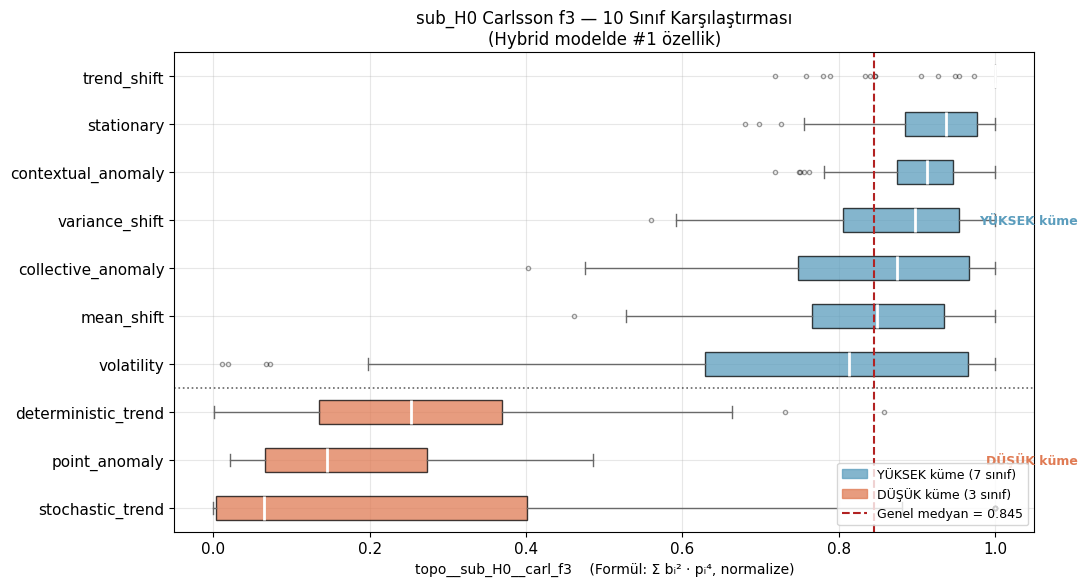

In [263]:
# ── Görsel 1: topo__sub_H0__carl_f3 — yatay boxplot, küme renklendirmesi ───────

feat_col   = 'topo__sub_H0__carl_f3'
all_merged = all_feat.merge(all_lbl[['series_id', 'primary_category']], on='series_id')

# Sınıfları medyana göre artan sırala (yatay boxplot: altta düşük, üstte yüksek)
order = (all_merged.groupby('primary_category')[feat_col]
         .median().sort_values(ascending=True).index.tolist())

# İki doğal küme (Bölüm 10 summary tablosundan)
HIGH_CLUSTER = {'trend_shift', 'stationary', 'contextual_anomaly',
                'variance_shift', 'collective_anomaly', 'mean_shift', 'volatility'}
LOW_CLUSTER  = {'stochastic_trend', 'point_anomaly', 'deterministic_trend'}

COLOR_HIGH = '#5b9dbd'   # mavi — yüksek persistence sınıfları
COLOR_LOW  = '#e07b54'   # turuncu — düşük persistence sınıfları

box_colors = [COLOR_LOW if c in LOW_CLUSTER else COLOR_HIGH for c in order]

data_by_class = [all_merged[all_merged['primary_category'] == cls][feat_col].values
                 for cls in order]

fig, ax = plt.subplots(figsize=(11, 6))

bp = ax.boxplot(data_by_class,
                vert=False,              # yatay: sınıf adları y ekseninde
                labels=order,
                patch_artist=True,
                notch=False,
                flierprops=dict(marker='o', markersize=3, alpha=0.4, linestyle='none'))

# Kutu renklerini kümeleye göre ata
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Bıyık ve ortanca çizgileri
for element in ('whiskers', 'caps', 'fliers'):
    for item in bp[element]:
        item.set_color('dimgray')
for median_line in bp['medians']:
    median_line.set(color='white', lw=2)

# Küme sınırı — LOW ve HIGH arasına yatay kesikli çizgi
low_count = sum(1 for c in order if c in LOW_CLUSTER)
ax.axhline(low_count + 0.5, color='black', lw=1.2, ls=':', alpha=0.6)

# Genel medyan — dikey kırmızı kesikli çizgi
overall_median = all_merged[feat_col].median()
ax.axvline(overall_median, color='firebrick', lw=1.5, ls='--',
           label=f'Genel medyan = {overall_median:.3f}')

# Küme etiketleri (sağ kenara)
low_y  = (low_count + 1) / 2
high_y = low_count + (len(order) - low_count + 1) / 2
ax.text(ax.get_xlim()[1] if ax.get_xlim()[1] > 0 else 1.05,
        low_y,  'DÜŞÜK küme',  va='center', ha='right',
        color=COLOR_LOW,  fontsize=9, fontweight='bold',
        transform=ax.get_yaxis_transform())
ax.text(ax.get_xlim()[1] if ax.get_xlim()[1] > 0 else 1.05,
        high_y, 'YÜKSEK küme', va='center', ha='right',
        color=COLOR_HIGH, fontsize=9, fontweight='bold',
        transform=ax.get_yaxis_transform())

ax.set_xlabel('topo__sub_H0__carl_f3    (Formül: Σ bᵢ² · pᵢ⁴, normalize)', fontsize=10)
ax.set_title('sub_H0 Carlsson f3 — 10 Sınıf Karşılaştırması\n'
             '(Hybrid modelde #1 özellik)', fontsize=12)
ax.legend(loc='lower right', fontsize=9)

# Legend: küme renkleri
legend_patches = [
    mpatches.Patch(color=COLOR_HIGH, alpha=0.75, label=f'YÜKSEK küme ({len(HIGH_CLUSTER)} sınıf)'),
    mpatches.Patch(color=COLOR_LOW,  alpha=0.75, label=f'DÜŞÜK küme ({len(LOW_CLUSTER)} sınıf)'),
]
ax.legend(handles=legend_patches +
          [plt.Line2D([0], [0], color='firebrick', ls='--', lw=1.5,
                      label=f'Genel medyan = {overall_median:.3f}')],
          loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

### Bu grafiği nasıl okumalı?

**X ekseni:** `topo__sub_H0__carl_f3` = $\sum b_i^2 \cdot p_i^4$ (normalize edilmiş, 0–1 arası).  
Her serinin tüm 16 sublevel/superlevel özelliğinin maksimumuna bölünür —  
yani değer "bu özellik o seri için ne kadar baskın?" sorusunu cevaplar.

**Kutular:** Her sınıfın 100 serisindeki dağılım.  
- Kutunun sol kenarı: 1. çeyrek (Q1)  
- İçindeki beyaz çizgi: medyan  
- Kutunun sağ kenarı: 3. çeyrek (Q3)  
- Bıyıklar: IQR × 1.5 sınırı; bıyık dışı noktalar aykırı değer

**İki küme arasındaki kesik çizgi:**

| Küme | Sınıflar | Neden yüksek/düşük? |
|------|----------|----------------------|
| YÜKSEK (≥ 0.80) | trend_shift, stationary, mean_shift, … | Bu seriler **yüksek seviyeli, uzun süren** barlar içerir (b yüksek, p büyük → b²·p⁴ büyük) |
| DÜŞÜK  (≤ 0.25) | stochastic_trend, point_anomaly, deterministic_trend | Bu serilerde carl_f3 baskın özellik **değil** — başka özellikler daha büyük |

**Neden `trend_shift` medyanı tam 1.0?**  
Normalize: her seri için 16 değerden maksimumu 1'e çekilir.  
`trend_shift` serilerinde **carl_f3 zaten en büyük özellik** olduğu için medyan ≈ 1.0 çıkar.

**Neden `stochastic_trend` kutusu geniş?**  
Rastsal yürüyüş (random walk): seriden seriye yapı tamamen farklı olabilir —  
bazen trend_shift gibi davranır, bazen düz gürültü gibi → büyük IQR.

**Neden `point_anomaly` düşük?**  
Sub_H0 bariyer barında **birth ≈ gürültü seviyesi** (b ≈ 0).  
Formülde $b^2$ çarpanı olduğu için küçük b, büyük persistence'ı da ezer:  
bar uzundur ama b ≈ 0 → $b^2 \cdot p^4$ ≈ 0.

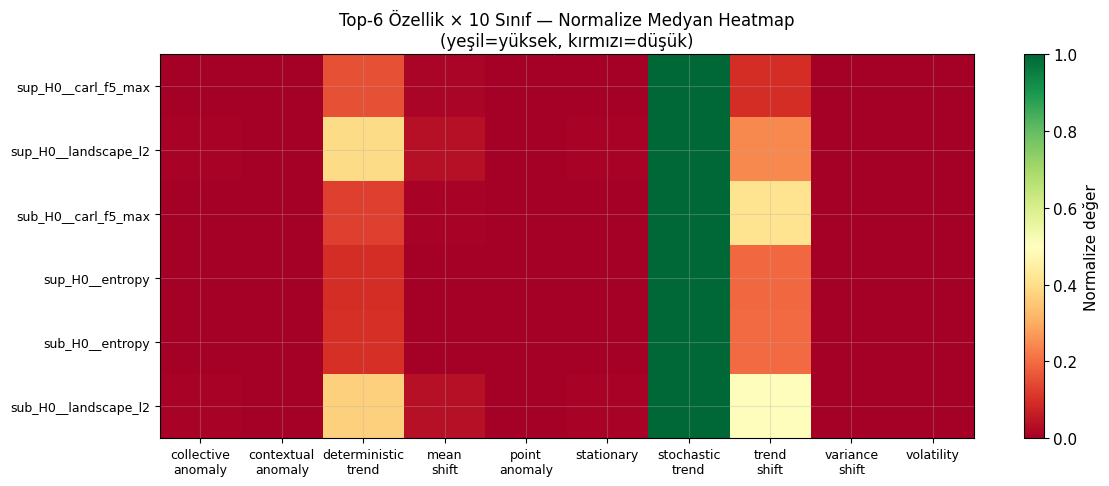

In [264]:
# ── Görsel 2: Top-6 özellik × 10 sınıf heatmap ───────────────────────────────

top6 = mi_series.nlargest(6).index.tolist()  # yüksekten düşüğe (en önemli üstte)

# Her sınıf için normalize medyan
pivot = (all_merged.groupby('primary_category')[top6]
         .median()
         .apply(lambda col: (col - col.min()) / (col.max() - col.min() + 1e-9)))

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(pivot.values.T, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(pivot.index)))
ax.set_xticklabels([c.replace('_', '\n') for c in pivot.index], fontsize=9)
ax.set_yticks(range(len(top6)))
ax.set_yticklabels([n.replace('topo__', '') for n in top6], fontsize=9)
ax.set_title('Top-6 Özellik × 10 Sınıf — Normalize Medyan Heatmap\n'
             '(yeşil=yüksek, kırmızı=düşük)')
plt.colorbar(im, ax=ax, label='Normalize değer')
plt.tight_layout()
plt.show()

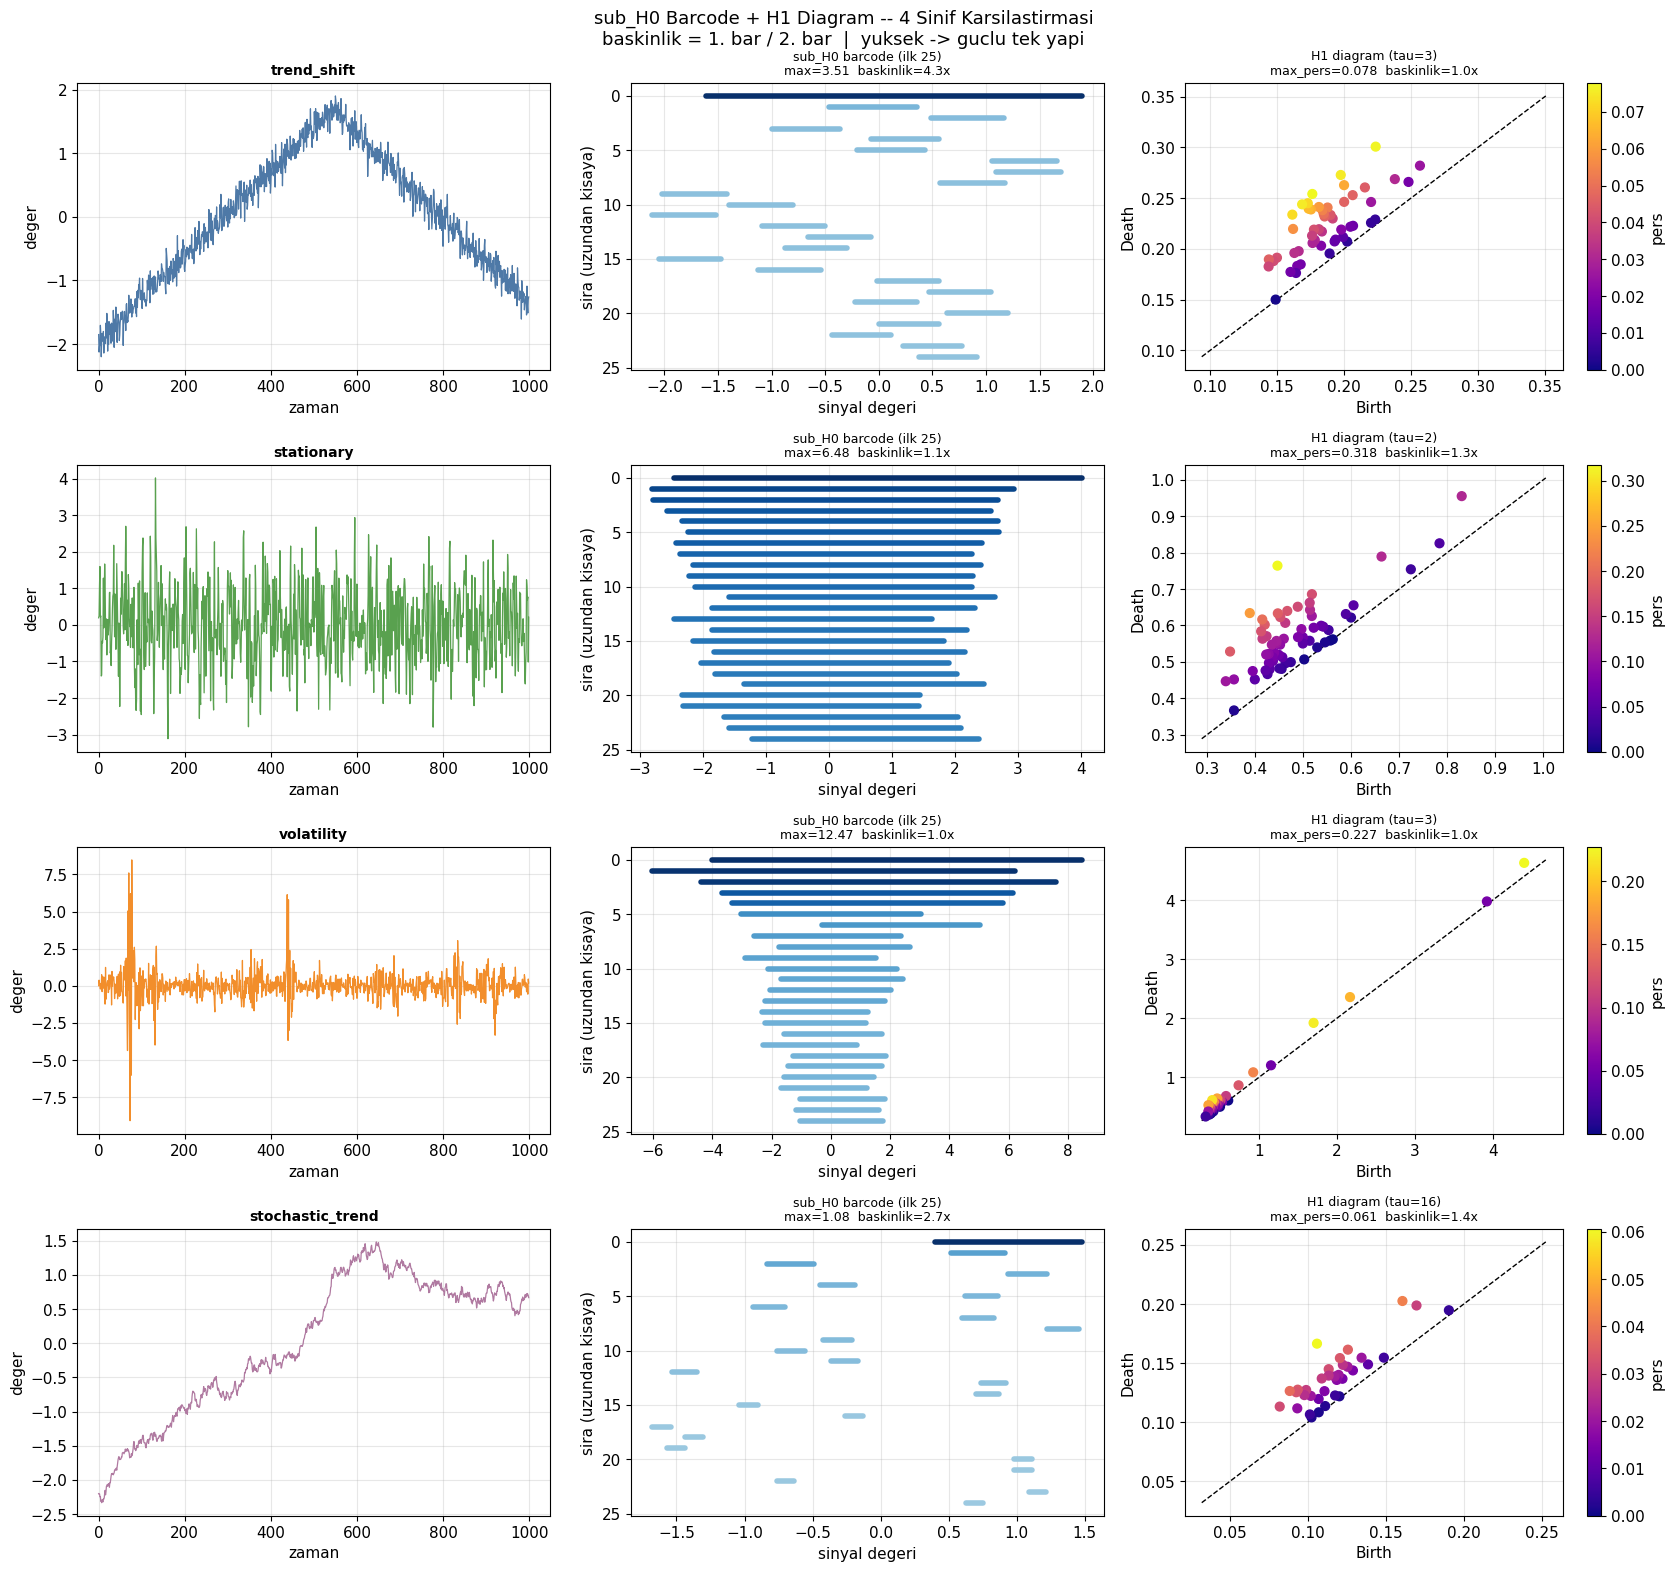

sub_H0 baskinlik ozeti:
  trend_shift             max_pers=3.508  baskinlik=4.3x
  stationary              max_pers=6.482  baskinlik=1.1x
  volatility              max_pers=12.473  baskinlik=1.0x
  stochastic_trend        max_pers=1.080  baskinlik=2.7x


In [265]:
# -- Gorsel 3: 4 sinif x (sinyal | sub_H0 barcode | H1 diagram) --
#
# sub_H0 barcode: sorted persistence bars -- '1 baskin bar' farkini en net gosterir
# H1 diagram   : Takens embedding ile dongusal yapi var mi?

COMPARE_CLASSES = ['trend_shift', 'stationary', 'volatility', 'stochastic_trend']

fig, axes = plt.subplots(4, 3, figsize=(17, 16))

for row, cls in enumerate(COMPARE_CLASSES):
    ts = example_series[cls].astype(float)

    # Sutun 0: Sinyal
    axes[row, 0].plot(ts, lw=0.9,
                      color=['#4e79a7','#59a14f','#f28e2b','#b07aa1'][row])
    axes[row, 0].set_title(cls, fontsize=10, fontweight='bold')
    axes[row, 0].set_xlabel('zaman'); axes[row, 0].set_ylabel('deger')

    # Sutun 1: sub_H0 sorted barcode
    sub_diag = _sub(ts)
    max_pers_s = 0.0
    dom_ratio  = 'N/A'
    if len(sub_diag):
        pers_s   = sub_diag[:, 1] - sub_diag[:, 0]
        pos_mask = pers_s > 1e-6
        pers_pos = pers_s[pos_mask]
        sub_pos  = sub_diag[pos_mask]
        if len(pers_pos):
            top_n   = min(25, len(pers_pos))
            idx_top = np.argsort(-pers_pos)[:top_n]
            cmap_s  = get_cmap('Blues')
            nrm_s   = Normalize(vmin=0, vmax=pers_pos.max())
            for rank, i in enumerate(idx_top):
                axes[row, 1].plot([sub_pos[i, 0], sub_pos[i, 1]],
                                  [rank, rank], lw=4, solid_capstyle='round',
                                  color=cmap_s(0.3 + 0.7 * nrm_s(pers_pos[i])))
            sorted_p  = np.sort(pers_pos)[::-1]
            max_pers_s = sorted_p[0]
            dom_ratio  = '{:.1f}x'.format(sorted_p[0] / sorted_p[1]) if len(sorted_p) > 1 else 'inf'
    axes[row, 1].set_title(
        'sub_H0 barcode (ilk {})\nmax={:.2f}  baskinlik={}'.format(top_n if len(sub_diag) else 0, max_pers_s, dom_ratio),
        fontsize=9)
    axes[row, 1].invert_yaxis()
    axes[row, 1].set_xlabel('sinyal degeri')
    axes[row, 1].set_ylabel('sira (uzundan kisaya)')

    # Sutun 2: H1 -- Takens embedding + Ripser
    try:
        tau_h1 = estimate_delay_mi(ts, max_lag=50)
        tau_h1 = max(1, min(tau_h1, len(ts) // 4))
        cloud  = np.column_stack([ts[:-tau_h1], ts[tau_h1:]])
        n_perm = min(150, len(cloud) - 1)
        res_h1 = ripser(cloud, maxdim=1, n_perm=n_perm)
        dgm_h1 = res_h1['dgms'][1]
        finite = dgm_h1[np.isfinite(dgm_h1[:, 1])]
        if len(finite):
            pers_h1 = finite[:, 1] - finite[:, 0]
            sc = axes[row, 2].scatter(
                finite[:, 0], finite[:, 1],
                c=pers_h1, cmap='plasma', s=40,
                vmin=0, vmax=pers_h1.max(), zorder=3)
            lo = finite.min() - 0.05; hi = finite.max() + 0.05
            axes[row, 2].plot([lo, hi], [lo, hi], 'k--', lw=1)
            plt.colorbar(sc, ax=axes[row, 2], label='pers')
            top_h1 = np.sort(pers_h1)[::-1]
            dom_h1 = '{:.1f}x'.format(top_h1[0] / top_h1[1]) if len(top_h1) > 1 else 'inf'
            axes[row, 2].set_title(
                'H1 diagram (tau={})\nmax_pers={:.3f}  baskinlik={}'.format(tau_h1, top_h1[0], dom_h1),
                fontsize=9)
        else:
            axes[row, 2].set_title('H1 (tau={})\n(sonlu bar yok)'.format(tau_h1), fontsize=9)
    except Exception as e:
        axes[row, 2].set_title('H1 -- hata: {}'.format(e), fontsize=8)
    axes[row, 2].set_xlabel('Birth'); axes[row, 2].set_ylabel('Death')

fig.suptitle(
    'sub_H0 Barcode + H1 Diagram -- 4 Sinif Karsilastirmasi\n'
    'baskinlik = 1. bar / 2. bar  |  yuksek -> guclu tek yapi',
    fontsize=13)
plt.tight_layout()
plt.show()

print('sub_H0 baskinlik ozeti:')
for cls in COMPARE_CLASSES:
    ts   = example_series[cls].astype(float)
    diag = _sub(ts)
    p    = np.sort(diag[:, 1] - diag[:, 0])[::-1]
    p    = p[p > 1e-6]
    dom  = '{:.1f}x'.format(p[0] / p[1]) if len(p) > 1 else 'inf'
    print('  {:22s}  max_pers={:.3f}  baskinlik={}'.format(cls, p[0], dom))

### Bu grid'i nasil okumali? — Onemli Cikis

**Goz alici celiski:**

| Sinif | sub_H0 max_pers | sub_H0 baskinlik |
|-------|-----------------|-------------------|
| `trend_shift` | 3.51 | **4.3x** (1 baskin bar) |
| `stationary` | **6.48** | 1.1x (esit barlar) |
| `volatility` | **12.47** | 1.0x (esit barlar) |
| `stochastic_trend` | 1.08 | 2.7x (orta baskinlik) |

> **"En uzun bar" sinif ayrimini saglamaz — baskinlik saglar.**
>
> `volatility` serileri yuksek genlik dalgalanmali oldugu icin max_pers cok yuksek (12.47),
> ama tum barlar benzer uzunlukta -> bilgi tek bir yapida toplanmamis. Buna karsilik
> `trend_shift` az sayida baskin bar uretir -> sinif imzasi daha keskin.

**H1 paneli:** Hicbir sinifta cok belirgin H1 yapisi yok (~periyodik degil hicbiri).
H1 ozelikleri Bolum 2 modelinde **destekleyici** rol oynar — kucuk farkliliklar bile
toplam 24-D vektorde sinifa ozgu desen olusturur.

**Pratik karar kurali (modeli anlamak icin):**
1. `sub_H0__carl_f3` yuksek mi? -> Bolum 11 boxplot'undaki YUKSEK kume
2. `sub_H0` entropy dusuk mu? -> Az sayida baskin bar (`trend_shift`, `point_anomaly` tipi)
3. H1 max_pers anlamli mi? -> Donguusal yapi (nadir, ama varsa guclu sinyal)

In [266]:
# ── Özet tablo: Topo özelliklerinin sınıf bazlı ayrım gücü ────────────────────

print('Sınıf bazlı sub_H0__carl_f3 medyanları (büyük → sınıf ayrımı kolay):')
print('=' * 55)
medians = (all_merged.groupby('primary_category')['topo__sub_H0__carl_f3']
           .median().sort_values(ascending=False))
max_val = medians.max()
for cls, val in medians.items():
    bar_len = max(0, int(val / (max_val + 1e-9) * 30))
    indicator = '▓' * bar_len + '░' * (30 - bar_len)
    print(f'{cls:25s} {val:8.4f}  {indicator}')

print()
print('Topoloji özelliklerinin avantajı:')
print('  • trend_shift, mean_shift gibi yapısal değişimler → yüksek persistence → iyi ayrım')
print('  • 18 özellik ile RandomForest %86.5 accuracy (100 TSFresh özelliğiyle %91.4)')
print('  • Oran: 5.3x daha verimli (özellik başına accuracy/feature)')


Sınıf bazlı sub_H0__carl_f3 medyanları (büyük → sınıf ayrımı kolay):
trend_shift                 1.0000  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓░
stationary                  0.9372  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓░░
contextual_anomaly          0.9129  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓░░░
variance_shift              0.8976  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓░░░░
collective_anomaly          0.8740  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓░░░░
mean_shift                  0.8488  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓░░░░░
volatility                  0.8124  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓░░░░░░
deterministic_trend         0.2533  ▓▓▓▓▓▓▓░░░░░░░░░░░░░░░░░░░░░░░
point_anomaly               0.1454  ▓▓▓▓░░░░░░░░░░░░░░░░░░░░░░░░░░
stochastic_trend            0.0645  ▓░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

Topoloji özelliklerinin avantajı:
  • trend_shift, mean_shift gibi yapısal değişimler → yüksek persistence → iyi ayrım
  • 18 özellik ile RandomForest %86.5 accuracy (100 TSFresh özelliğiyle %91.4)
  • Oran: 5.3x daha verimli (özellik başına accuracy/feature)


---
## Özet

| Kavram | Bölüm | Anahtar fikir |
|--------|-------|---------------|
| Sublevel H0 | 1-2 | Vadiler → barlar; uzun = anlamlı |
| Spike tespiti | 3 | Spike bariyer barı yaratır (sub_H0); sup_H0'da essential class olur |
| Takens + H1 | 4 | Döngüsellik → çember → 1 uzun H1 bar |
| Vektörizasyon | 5 | 8 sayı: Carlsson×5 + entropy + L1 + L2 |
| `topology_extraction.py` | 6-8 | CombinedExtractor → 24 özellik |
| Batch pipeline | 9 | 1000 seri, Parallel, features.parquet |
| MI seçimi | 10 | 24 → 18 (carl_f5_max + landscape_l2 düştü) |
| Sınıf analizi | 11 | trend_shift için güçlü, stationary için zor |

### Essential Class Notu
> Bir sinyalin **global maksimumu** superlevel filtrasyon için "essential class"tır —  
> sonsuza kadar yaşar, sonlu barcode'da **görünmez**.  
> Bu yüzden izole spike'lar **sub_H0** üzerinden yakalanır:  
> spike bir bariyer koyar, komşu vadilerin ölüm değeri = spike yüksekliği.

**Kod referansı:**
- `02-preprocessing/topology_extraction.py` — tüm extraction kodu
- `02-preprocessing/feature_selection.py` — MI tabanlı seçim
- `03-models/` — classification modelleri
